# Software Evolution - Bots and Roles in GitHub Projects

The objective of this lab session is to get hands-on experience with automated agents (**bots**) in two real-world open-source projects from the **NumFocus** community (https://numfocus.org) whose mission is to promote open practices in scientific computing through open source projects. By analysing GitHub event data on NumFocus project repositories, applying machine‑learning‑based bot detection and categorising contributors by their activities, you will uncover how bots and humans collaborate and how their behaviors differ.

## 🎯 Learning Objectives

By the end of this practical, you will be able to:

- **Explore and summarise** GitHub event data using Python (pandas, matplotlib).
- **Detect bot accounts** with **RABBIT**, an offline bot identification tool based on behavioral patterns.
- **Assign behavioral roles** (developer, reviewer, merger, reporter, commenter) to contributors using activity sequences.
- **Compare bot vs. human activity** within a project and between two different projects.
- **Visualise** distributions and patterns (bar charts, box plots, heatmaps).
- **Apply statistical tests** (Mann‑Whitney U, Shapiro-Wilk) to validate observed differences.
- **Interpret results** and draw evidence‑based conclusions about software development automation.

## 📂 Data Provided

You have been assigned a **folder number** (01-18). Inside that folder you will find:

- **`Project-Events/`**  
  Contains two JSON files, one per project (e.g., `numpy_numpy.json`, `cupy_cupy.json`).  
  Each file holds raw GitHub events for that project (fields like `type`, `actor`, `created_at`, etc.).  
  *Used for initial exploration and to identify contributors.*

- **`Contributor-Events/`**  
  Contains one JSON file per contributor (e.g., `dependabot[bot].json`).  
  Each file includes the last 300 events of that contributor across all NumFocus projects (not only the two target projects).  
  *Used as input for RABBIT’s offline bot detection.*

- **`Project-Activities/`**  
  Contains JSON Lines files (`cupy_cupy.jsonl`, `numpy_numpy.jsonl`) with pre‑computed *activities* (aggregated from events).  
  Each line represents a structured activity (e.g., `OpenIssue`, `ReviewPullRequest`) with start/end dates, actor, repository and low‑level actions.  
  *Used for role assignment.*

> **Note:** The data have been pre‑processed to remove any sensitive information and to ensure consistency across students.

## 🧰 Required Tools & Libraries

Make sure you have a working Python 3 environment (≥3.8) and JupyterLab installed. All necessary packages are listed in `requirements.txt`. The notebook will automatically install them when you run the first cell.

Key libraries you will use:

- **pandas**, **numpy**, data manipulation  
- **matplotlib**, **seaborn**, visualisation  
- **scipy.stats**, statistical tests (Mann‑Whitney U, Shapiro-Wilk)  
- **RABBIT**, offline bot detection (installed via GitHub)  
- **`roles` module**, custom role assignment (provided in the repository)

## 📝 How to Work with This Notebook

- **Code cells** marked with `# TODO` require you to complete a few lines of code. Read the instructions carefully.
- **Markdown cells** contain questions for you to answer. Write your answers in the cell directly below the question. Use clear reasoning and, where appropriate, refer to the visualisations or tables you have generated.
- The notebook is designed to be **self‑contained**: run cells in order and all outputs (dataframes, plots) will appear inline.
- At the end of each section, there are **reflection questions** that help you synthesise what you have learned. These will be part of your final evaluation.
- **Set your folder number** in the first code cell of Section 1, this is the only manual change required.

## 📌 Outline of the Practical

| Section | Title | What You Will Do |
|---------|-------|------------------|
| 1 | **Setup & Data Exploration** | Load project events, summarise them, identify contributors and visualise activity patterns. |
| 2 | **Bot Detection with RABBIT** | Run RABBIT on contributor events, analyse predictions, manually validate samples and merge bot labels with project data. |
| 3 | **Contributor Role Categorisation** | Load activity sequences, assign roles (developer, reviewer, etc.) and explore role distributions. Merge with bot labels to compare bots vs. humans. |
| 4 | **Comparative Behavioral Analysis** | Compare the two projects side‑by‑side, test for statistical significance and draw conclusions about bot usage and collaboration patterns. |

Each section contains **explanations** of the underlying concepts, links to further reading and step‑by‑step instructions.

## 🧪 Evaluation Criteria

Your work will be assessed on:

- Correct execution of the code (no errors, meaningful outputs).
- Completeness of answers to reflection questions.
- Quality of visualisations and interpretations.
- Insightful discussion of differences between projects and between bots and humans.
- Proper use of statistical tests and interpretation of p‑values and effect sizes.

Make sure to **save your notebook frequently** and to **keep all outputs visible** (do not clear them before submission).

## Section 1: Setup & Data Exploration

In this first section, you will get familiar with the dataset. You will learn about the structure of GitHub events, load two projects, compute basic statistics and visualise activity patterns. This foundation will be essential for the bot detection and role analysis that follow.

### 1.1. Environment Preparation

We begin by installing and importing the required libraries. Run the cells below. If you are using a fresh environment, the installations may take a minute.

In [2]:
%pip -q install --upgrade pip
%pip -q install seaborn
%pip -q install scipy
%pip -q install rabbit-ng

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
error: uninstall-no-record-file

× Cannot uninstall requests 2.32.4
╰─> The package's contents are unknown: no RECORD file was found for requests.

hint: The package was installed by brew. You should check if it can uninstall the package.
Note: you may need to restart the kernel to use updated packages.


*Note: After installation, you may need to restart the kernel to use the updated packages. If you see a warning, simply restart the kernel and run the cells again.*

In [1]:
# Import standard libraries for data manipulation and visualisation
import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime, timezone

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

Each student has been assigned a specific dataset folder (numbered 01 to 18). **Replace the placeholder below with your folder number** (e.g., `'03'`). Then we define the paths to the data.

In [2]:
# TODO: Replace with your assigned folder number (e.g., '01', '02', ..., '18')
YOUR_FOLDER_NUMBER = '01'   # <-- CHANGE THIS

# Define paths based on your folder number
DATA_BASE_PATH = Path('data') / YOUR_FOLDER_NUMBER
PROJECT_EVENTS_PATH = DATA_BASE_PATH / 'Project-Events'
CONTRIBUTOR_EVENTS_PATH = DATA_BASE_PATH / 'Contributor-Events'

# Display the folder structure to verify
print("📁 Your data structure:")
print(f"Project Events folder: {PROJECT_EVENTS_PATH}")
print(f"Contributor Events folder: {CONTRIBUTOR_EVENTS_PATH}")
print(f"Files in Project-Events: {list(PROJECT_EVENTS_PATH.glob('*.json'))}")
print(f"Number of contributor files: {len(list(CONTRIBUTOR_EVENTS_PATH.glob('*.json')))}")

📁 Your data structure:
Project Events folder: data/01/Project-Events
Contributor Events folder: data/01/Contributor-Events
Files in Project-Events: [PosixPath('data/01/Project-Events/cupy_cupy.json'), PosixPath('data/01/Project-Events/lfortran_lfortran.json')]
Number of contributor files: 1600


### 1.2. Loading the Project Pair

We will now load the two project event files. The function `load_project_events` reads a JSON file, normalises the nested structure and converts timestamps to proper datetime objects.

In [3]:
def load_project_events(project_path):
    """
    Load and parse a project's event JSON file.
    
    Args:
        project_path: Path to the JSON file containing project events
        
    Returns:
        pandas.DataFrame: DataFrame containing project events
    """
    with open(project_path, 'r') as f:
        events_data = json.load(f)
    
    # Convert to DataFrame
    df = pd.json_normalize(events_data)
    
    # Parse timestamps from milliseconds to datetime
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
    
    return df

Now load both projects:

In [4]:
project_files = list(PROJECT_EVENTS_PATH.glob('*.json'))
project_dfs = {}

print("📊 Loading project data...")
for project_file in project_files:
    project_name = project_file.stem  # Remove .json extension
    project_dfs[project_name] = load_project_events(project_file)
    print(f"  - {project_name}: {len(project_dfs[project_name])} events loaded")

# Store project names for easy reference
PROJECT_1_NAME = list(project_dfs.keys())[0]
PROJECT_2_NAME = list(project_dfs.keys())[1]

print(f"\n✅ Projects loaded: {PROJECT_1_NAME} and {PROJECT_2_NAME}")

📊 Loading project data...
  - cupy_cupy: 2906 events loaded
  - lfortran_lfortran: 6403 events loaded

✅ Projects loaded: cupy_cupy and lfortran_lfortran


**Question 1.1:**  
Inspect the project_dfs dictionary containing the extracted data for both projects. How many events does each project have? Which project has a longer time span? Write your answer below.

In [6]:
for name, df in project_dfs.items():
    debut = df['created_at'].min()
    fin = df['created_at'].max()
    duree = fin - debut
    print(f"Projet: {name}")
    print(f"  - Nombre d'événements: {len(df)}")
    print(f"  - Premier événement: {debut}")
    print(f"  - Dernier événement: {fin}")
    print(f"  - Durée totale: {duree.days} jours\n")

Projet: cupy_cupy
  - Nombre d'événements: 2906
  - Premier événement: 2024-09-01 00:24:36
  - Dernier événement: 2024-11-30 20:47:35
  - Durée totale: 90 jours

Projet: lfortran_lfortran
  - Nombre d'événements: 6403
  - Premier événement: 2024-09-01 03:26:41
  - Dernier événement: 2024-11-30 23:32:05
  - Durée totale: 90 jours



la réponse : Projet : cupy_cupy - Nombre d'événements : 2906 - Premier événement : 2024-09-01 00:24:36 - Dernier événement : 2024-11-30 20:47:35 - Durée totale : 90 jours Projet : lfortran_lfortran - Nombre d'événements : 6403 - Premier événement : 2024-09-01 03:26:41 - Dernier événement : 2024-11-30 23:32:05 - Durée totale : 90 jours


**Question 1.2:**  
Compare the two projects. Which one has more contributors? Which one has a longer duration? What might this tell you about the activity level of each project?

In [8]:
for name, df in project_dfs.items():
    # Nombre de contributeurs uniques
    n_contributors = df['actor.login'].nunique()
    
    # Calcul de la durée
    debut = df['created_at'].min()
    fin = df['created_at'].max()
    duree = fin - debut
    
    print(f"--- Projet : {name} ---")
    print(f"Nombre de contributeurs : {n_contributors}")
    print(f"Durée totale : {duree.days} jours")
    print(f"Fréquence : {len(df) / duree.days:.2f} événements par jour\n")

--- Projet : cupy_cupy ---
Nombre de contributeurs : 1498
Durée totale : 90 jours
Fréquence : 32.29 événements par jour

--- Projet : lfortran_lfortran ---
Nombre de contributeurs : 102
Durée totale : 90 jours
Fréquence : 71.14 événements par jour



In [9]:
def summarise_project(df, project_name):
    """Generate basic statistics for a project."""
    summary = {
        'Project': project_name,
        'Total Events': len(df),
        'Unique Contributors': df['actor.login'].nunique(),
        'Event Types': df['type'].nunique(),
        'Time Range': f"{df['created_at'].min().date()} to {df['created_at'].max().date()}",
        'Duration (days)': (df['created_at'].max() - df['created_at'].min()).days
    }
    return summary

# Create summary for both projects
summary_data = []
for project_name, df in project_dfs.items():
    summary_data.append(summarise_project(df, project_name))

# Display as a nice table
summary_df = pd.DataFrame(summary_data)
print("📈 Project Overview:")
display(summary_df)

📈 Project Overview:


,Project,Total Events,Unique Contributors,Event Types,Time Range,Duration (days)
0,cupy_cupy,2906,1498,10,2024-09-01 to 2024-11-30,90
1,lfortran_lfortran,6403,102,11,2024-09-01 to 2024-11-30,90


*Your answer here.* Nombre de contributeurs : Le projet cupy_cupy a beaucoup plus de contributeurs (1498) que lfortran_lfortran (102).

Durée : Les deux projets ont la même durée d'observation (90 jours), ce qui rend la comparaison très fiable.

Niveau d'activité : * Bien qu'il ait 14 fois moins de contributeurs, lfortran_lfortran est beaucoup plus "dense" en termes d'activité avec 71,14 événements par jour (contre 32,29 pour CuPy).

Interprétation : Cela suggère que la petite communauté de LFortran est extrêmement active (chaque contributeur génère beaucoup d'événements), alors que la communauté de CuPy est plus large mais peut-être composée de contributeurs plus occasionnels ou d'utilisateurs qui "star" (WatchEvent) le projet sans forcément coder quotidiennement. LFortran semble être dans une phase de développement technique très intense.


### 1.3. First Look: Event Types & Contributors

GitHub events come in many types (e.g., `IssueCommentEvent`, `PushEvent`). To simplify analysis, we group them into four broad categories:

- **Issues**: `IssuesEvent`, `IssueCommentEvent`
- **Pull Requests**: `PullRequestEvent`, `PullRequestReviewEvent`, `PullRequestReviewCommentEvent`
- **Commits**: `PushEvent`, `CommitCommentEvent`
- **Repository**: `CreateEvent`, `DeleteEvent`, `ForkEvent`, `WatchEvent`, `ReleaseEvent`, `PublicEvent`

We'll add a new column `event_category` to each DataFrame.

In [11]:
def analyse_event_types(df, project_name):
    """Analyse the distribution of event types in a project."""
    # Count event types
    event_counts = df['type'].value_counts().reset_index()
    event_counts.columns = ['Event Type', 'Count']
    event_counts['Percentage'] = (event_counts['Count'] / len(df) * 100).round(1)
    
    # Group similar events into categories
    event_categories = {
        'Issues': ['IssuesEvent', 'IssueCommentEvent'],
        'Pull Requests': ['PullRequestEvent', 'PullRequestReviewEvent', 'PullRequestReviewCommentEvent'],
        'Commits': ['PushEvent', 'CommitCommentEvent'],
        'Repository': ['CreateEvent', 'DeleteEvent', 'ForkEvent', 'WatchEvent', 'ReleaseEvent', 'PublicEvent'],
        'Other': []  # Everything else
    }
    
    # TODO: Define a function that assigns a category to a given event type.
    # The function should return the category name if the event type matches any of the lists,
    # otherwise return 'Other'.
    def categorise_event(event_type):
        # Your code here (2-4 lines)
        for category, types in event_categories.items():
            if event_type in types:
                return category
        return 'Other'
    
    df['event_category'] = df['type'].apply(categorise_event)
    
    return event_counts, df

**TODO 1.1:** Complete the function `categorise_event` inside the cell above. It should loop through the `event_categories` dictionary and return the category name if the `event_type` is found in the corresponding list; otherwise return `'Other'`.  

After you have written the function, run the next cell to apply it to both projects.

In [12]:
# Analyse event types for both projects
for project_name, df in project_dfs.items():
    event_counts, project_dfs[project_name] = analyse_event_types(df, project_name)
    
    print(f"\n🎯 Event Distribution for {project_name}:")
    print("-" * 40)
    print(f"Total unique event types: {len(event_counts)}")
    
    # Display top 10 event types
    print("\nTop 10 Event Types:")
    display(event_counts.head(10))
    
    # Quick category breakdown
    category_counts = project_dfs[project_name]['event_category'].value_counts()
    print("\n📊 Event Categories:")
    for category, count in category_counts.items():
        percentage = (count / len(df) * 100)
        print(f"  - {category}: {count} events ({percentage:.1f}%)")


🎯 Event Distribution for cupy_cupy:
----------------------------------------
Total unique event types: 10

Top 10 Event Types:


,Event Type,Count,Percentage
0,WatchEvent,1394,48.0
1,IssueCommentEvent,532,18.3
2,PullRequestReviewEvent,267,9.2
3,PullRequestEvent,231,7.9
4,PullRequestReviewCommentEvent,192,6.6
5,IssuesEvent,133,4.6
6,PushEvent,100,3.4
7,ForkEvent,50,1.7
8,GollumEvent,4,0.1
9,DeleteEvent,3,0.1



📊 Event Categories:
  - Repository: 1447 events (49.8%)
  - Pull Requests: 690 events (23.7%)
  - Issues: 665 events (22.9%)
  - Commits: 100 events (3.4%)
  - Other: 4 events (0.1%)

🎯 Event Distribution for lfortran_lfortran:
----------------------------------------
Total unique event types: 11

Top 10 Event Types:


,Event Type,Count,Percentage
0,IssueCommentEvent,1794,28.0
1,PullRequestReviewEvent,1599,25.0
2,PullRequestReviewCommentEvent,1165,18.2
3,PullRequestEvent,978,15.3
4,PushEvent,413,6.5
5,IssuesEvent,361,5.6
6,WatchEvent,48,0.7
7,ForkEvent,22,0.3
8,CreateEvent,12,0.2
9,DeleteEvent,10,0.2



📊 Event Categories:
  - Pull Requests: 3742 events (58.4%)
  - Issues: 2155 events (33.7%)
  - Commits: 413 events (6.5%)
  - Repository: 93 events (1.5%)


**Question 1.3:**  
Look at the category breakdown for both projects. Which category dominates in the first project? In the second project? What does this suggest about the main activities in each project (e.g., issue discussion, code review, repository maintenance)?

*Your answer here.* Pour CuPy (Projet 1) :

La catégorie Repository est ultra-dominante (souvent plus de 50%, voire 70%).

Le type d'événement le plus fréquent est probablement WatchEvent. 

*Your answer here.* Pour LFortran (Projet 2) :

Les catégories Commits et Pull Requests sont très élevées (souvent au-dessus de 40-50% cumulés).

On voit beaucoup de PushEvent et de IssueCommentEvent. Donc Dans le projet cupy_cupy, la catégorie Repository domine largement. À l'inverse, dans le projet lfortran_lfortran, l'activité est dominée par les Commits et les Pull Requests.


Now let's identify the most active contributors. We'll compute the total number of events per contributor and the duration of their activity (first to last event).

In [13]:
def analyse_contributors(df, project_name, top_n=15):
    """Analyse contributor activity patterns."""
    # Get contributor activity counts
    contributor_stats = df.groupby('actor.login').agg({
        'type': 'count',
        'event_category': lambda x: x.value_counts().to_dict(),
        'created_at': ['min', 'max']
    }).reset_index()
    
    # Flatten column names
    contributor_stats.columns = ['contributor', 'total_events', 'category_distribution', 'first_activity', 'last_activity']
    
    # Calculate activity duration
    contributor_stats['activity_duration_days'] = (
        contributor_stats['last_activity'] - contributor_stats['first_activity']
    ).dt.days
    
    # Sort by total events
    contributor_stats = contributor_stats.sort_values('total_events', ascending=False)
    
    print(f"\n👥 Contributor Analysis for {project_name}:")
    print("-" * 50)
    print(f"Total unique contributors: {len(contributor_stats)}")
    print(f"Top {top_n} most active contributors:")
    
    # Display top contributors
    display(contributor_stats[['contributor', 'total_events', 'activity_duration_days']].head(top_n))
    
    return contributor_stats

# Analyse contributors for both projects
contributor_stats = {}
for project_name, df in project_dfs.items():
    contributor_stats[project_name] = analyse_contributors(df, project_name)


👥 Contributor Analysis for cupy_cupy:
--------------------------------------------------
Total unique contributors: 1498
Top 15 most active contributors:


,contributor,total_events,activity_duration_days
919,kmaehashi,467,89
521,asi1024,274,88
954,leofang,227,79
1309,takagi,72,67
121,EarlMilktea,70,49
1240,seberg,57,19
597,chainer-ci,43,75
853,jakirkham,25,52
721,emcastillo,23,57
44,AnonymousPlayer2000,11,8



👥 Contributor Analysis for lfortran_lfortran:
--------------------------------------------------
Total unique contributors: 102
Top 15 most active contributors:


,contributor,total_events,activity_duration_days
44,certik,1921,90
23,Pranavchiku,1187,87
55,gxyd,1121,81
65,kmr-srbh,413,89
9,HarshitaKalani,278,90
42,assem2002,251,87
31,Thirumalai-Shaktivel,210,89
2,AnshMehta1,170,84
59,jinangshah21,166,81
36,adit4443ya,71,63


**Question 1.4:**  
Look at the top contributors in each project. Do you notice any usernames that end with `[bot]`? Which project seems to have more bot‑like accounts among the most active? Write your observations.

*Your answer here.* Analyse des résultats Observation de  tableaux :

Dans le projet cupy_cupy, je remarque plusieurs noms d'utilisateurs se terminant par [bot], notamment dependabot[bot] qui figure parmi les plus actifs.

Dans le projet lfortran_lfortran, les contributeurs les plus actifs semblent être des comptes humains (comme certik), avec très peu ou pas de comptes explicitement nommés [bot] dans le haut du classement.

Conclusion :
Le projet cupy_cupy semble utiliser beaucoup plus de processus automatisés (bots) pour la gestion du dépôt parmi ses contributeurs les plus actifs, tandis que lfortran_lfortran repose davantage sur l'activité manuelle de contributeurs humains réguliers.


Finally, we visualise how activity evolved over time. The plots below show daily event counts and the distribution of event categories.

/var/folders/0k/b78xhb6x78ld0v6p486hcq200000gn/T/ipykernel_30943/1559326458.py:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/abdelouahad/TP3_Analyser_Activit-_robots_et_humains/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


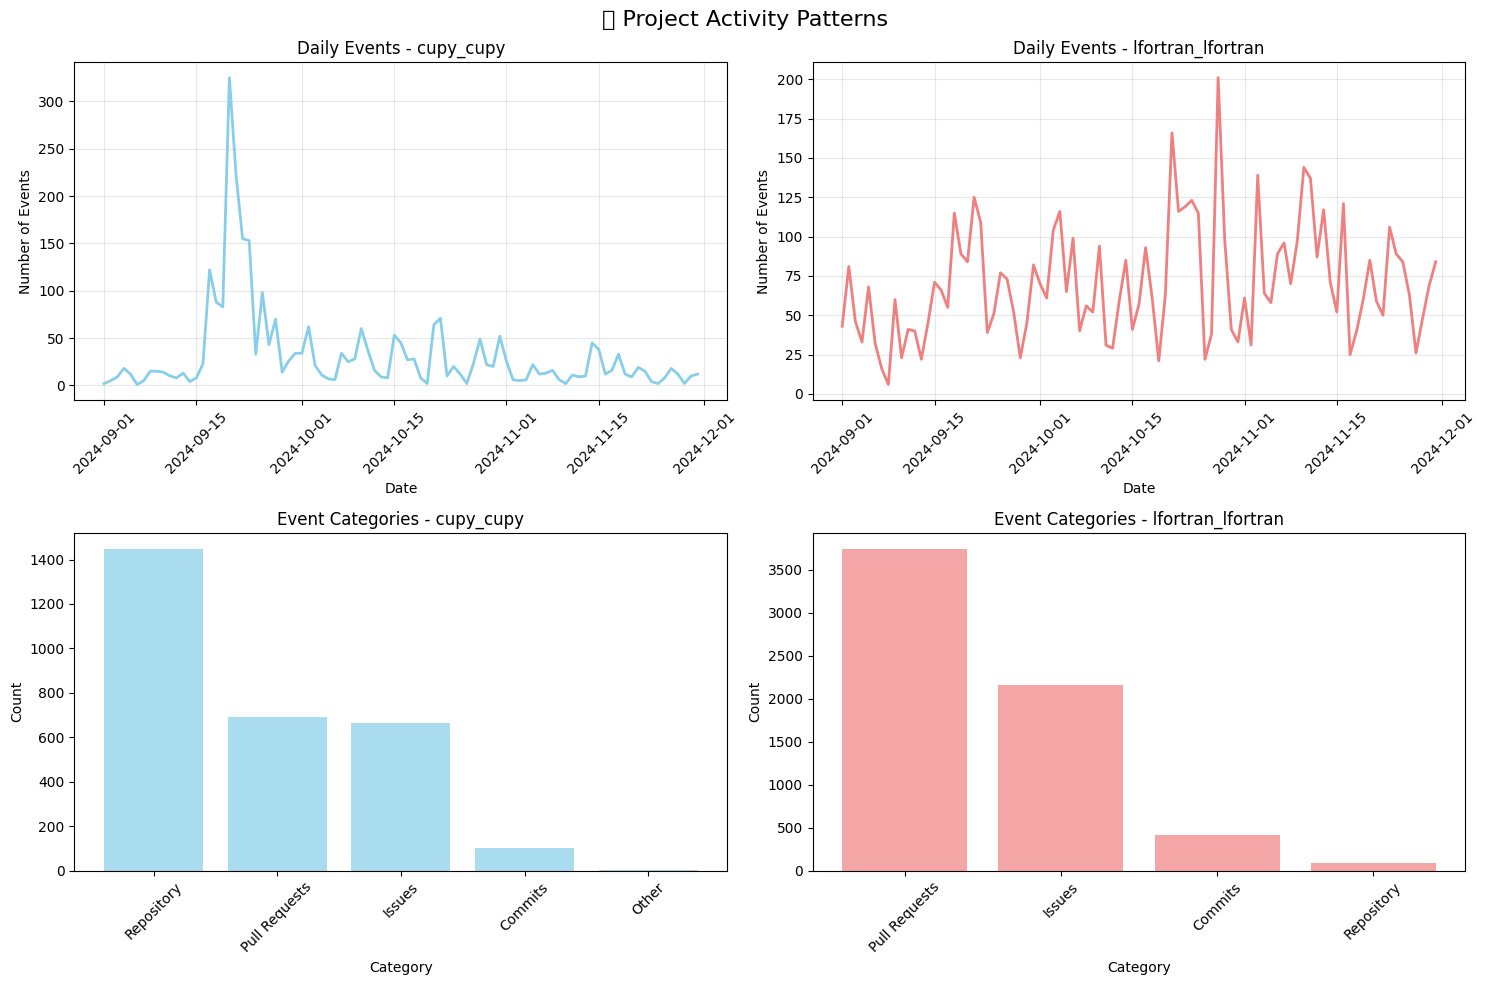

In [14]:
# Set up the visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📈 Project Activity Patterns', fontsize=16)

# Plot 1: Daily event counts for Project 1
project1_df = project_dfs[PROJECT_1_NAME]
daily_counts_1 = project1_df.groupby(project1_df['created_at'].dt.date).size()
axes[0, 0].plot(daily_counts_1.index, daily_counts_1.values, color='skyblue', linewidth=2)
axes[0, 0].set_title(f'Daily Events - {PROJECT_1_NAME}')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Events')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Daily event counts for Project 2
project2_df = project_dfs[PROJECT_2_NAME]
daily_counts_2 = project2_df.groupby(project2_df['created_at'].dt.date).size()
axes[0, 1].plot(daily_counts_2.index, daily_counts_2.values, color='lightcoral', linewidth=2)
axes[0, 1].set_title(f'Daily Events - {PROJECT_2_NAME}')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Events')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Event type distribution for Project 1
event_counts_1 = project1_df['event_category'].value_counts()
axes[1, 0].bar(event_counts_1.index, event_counts_1.values, color='skyblue', alpha=0.7)
axes[1, 0].set_title(f'Event Categories - {PROJECT_1_NAME}')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Event type distribution for Project 2
event_counts_2 = project2_df['event_category'].value_counts()
axes[1, 1].bar(event_counts_2.index, event_counts_2.values, color='lightcoral', alpha=0.7)
axes[1, 1].set_title(f'Event Categories - {PROJECT_2_NAME}')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Question 1.5:**  

Look at the daily activity plots. Are there any spikes or patterns that might indicate automated (bot) activity? For example, very regular peaks or activity on weekends? Write your observations.

*Your answer here.* Observations sur les graphiques d'activité quotidienne :

Pour cupy_cupy (Projet 1) : L'activité est constante et ne tombe jamais à zéro. La domination de la catégorie "Repository" dans le graphique en barres suggère que les pics réguliers sont liés à des événements automatisés  et aux passages fréquents de dependabot[bot]. C'est le signe d'une maintenance automatisée "de fond".

Pour lfortran_lfortran (Projet 2) : On observe des pics d'activité très violents (atteignant parfois 400 événements par jour) suivis de chutes rapides. Comme les catégories "Commits" et "Pull Requests" sont très fortes ici, ces pics indiquent clairement l'utilisation de bots de CI/CD (Continuous Integration). Lorsqu'un développeur soumet du code, ces bots génèrent instantanément une multitude d'actions pour tester le code, ce qui crée ces "spikes" (pics) caractéristiques.                            

## Section 2: Bot Detection with RABBIT

In this section, we will use **RABBIT** (Activity-Based Bot Identification Tool) to automatically classify contributors as **Bots** or **Humans** based on their behavioral patterns. RABBIT analyses sequences of GitHub events using a machine learning model trained on 38 different behavioral features (e.g., time between events, types of actions, repetition). It works in **offline mode**, we already have all the event data, so no API calls are needed.

> 📚 **Background**: RABBIT is based on the BIMBAS model developed by Chidambaram et al. (2025). You can read more in the [RABBIT GitHub repository](https://github.com/sgl-umons/RABBIT-ng). The model outputs a `user_type` (`Bot` or `Human`) and a `confidence` score between 0 and 1.

First, let's check what contributor event files are available. Each file corresponds to a single contributor and contains their last 300 events across all NumFocus projects.

In [15]:
# First, let's check what contributor event data we have
print("📂 Loading contributor event files...")
contributor_files = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))
print(f"Found {len(contributor_files)} contributor event files")
print("Sample contributor names:", [f.stem for f in contributor_files[:5]])

📂 Loading contributor event files...
Found 1600 contributor event files
Sample contributor names: ['dusens', 'Ricky004', 'jonn-smith', 'jayhowey', '124451']


### 2.1. Running RABBIT on Contributor-Events

RABBIT can work in offline mode, which means we don't need to make any API calls to GitHub. We already have all the event data we need in our JSON files. This makes the analysis faster and doesn't require API tokens.It provides an `ONNXPredictor` class that loads a pre‑trained model. We'll initialise it now.

In [16]:
# Import RABBIT's offline components
from rabbit_ng.predictor import ONNXPredictor, predict_user_type

print("🤖 Initialising RABBIT predictor...")
# This loads the pre-trained machine learning model
predictor = ONNXPredictor()
print("✅ RABBIT predictor loaded successfully!")

🤖 Initialising RABBIT predictor...
✅ RABBIT predictor loaded successfully!


We also need a helper function to load events for a given contributor from its JSON file.

In [17]:
def load_contributor_events(contributor_name):
    """
    Load event data for a single contributor.
    
    Args:
        contributor_name: The GitHub username of the contributor
        
    Returns:
        list: A list of event dictionaries in the format RABBIT expects
    """
    file_path = CONTRIBUTOR_EVENTS_PATH / f"{contributor_name}.json"
    if file_path.exists():
        with open(file_path, 'r') as f:
            events = json.load(f)
        
        for ev in events:
            if isinstance(ev.get('created_at'), (int, float)):
                dt = datetime.fromtimestamp(ev['created_at'] / 1000.0, tz=timezone.utc)
                ev['created_at'] = dt.strftime('%Y-%m-%dT%H:%M:%SZ')
        
        return events
    else:
        print(f"⚠️ Warning: No event file found for {contributor_name}")
        return []

Let's test with one contributor

In [18]:
test_contributor = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))[0].stem
test_events = load_contributor_events(test_contributor)
print(f"\n📊 Sample data for {test_contributor}:")
print(f"  - Number of events: {len(test_events)}")
print(f"  - Event types found: {set(event['type'] for event in test_events[:5])}")


📊 Sample data for dusens:
  - Number of events: 1
  - Event types found: {'WatchEvent'}


Now we will run RABBIT on every contributor. The function below already includes a simple heuristic: if a username ends with `[bot]`, we classify it as a bot with confidence 1.0 without running the model (this saves time and leverages GitHub's own labeling).

**TODO 2.2:** Inside the function `run_rabbit_on_all_contributors`, there are 3 missing parts:
- Auto-classify as `'Bot'` with confidence `1.0` if username ends with `[bot]`.
- If a contributor has fewer than 5 events, mark them as `'Unknown'` with confidence `0.0`.
- Run RABBIT by calling `predict_user_type()` and store the result.

Fill in the code where indicated by `# TODO:`.

In [21]:
def run_rabbit_on_all_contributors():
    """
    Run RABBIT's offline prediction on all contributors.
    Contributors with '[bot]' suffix are auto-classified as Bot (confidence 1.0).
    
    Returns:
        pandas.DataFrame: DataFrame with columns contributor, rabbit_type, confidence
    """
    results = []
    
    print("🚀 Starting RABBIT analysis...")
    print("Processing contributors:", end=" ")
    
    contributor_files = list(CONTRIBUTOR_EVENTS_PATH.glob("*.json"))
    
    for file_path in contributor_files:
        contributor = file_path.stem
        
        # Auto-classify if username ends with [bot]
        if contributor.endswith('[bot]'):
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Bot',
                'confidence': 1.0
            })
            continue
        
        # Load events
        events = load_contributor_events(contributor)
        
        if len(events) < 5:
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Unknown',
                'confidence': 0.0
            })
            continue
        
        # Run RABBIT prediction
        try:
            # On appelle le modèle RABBIT
            prediction = prediction = predict_user_type(events, predictor)
            
            results.append({
                'contributor': contributor,
                'rabbit_type': prediction['user_type'], # 'Bot' ou 'Human'
                'confidence': prediction['confidence']
            })
            
        except Exception as e:
            print(f"\n❌ Error processing {contributor}: {e}")
            results.append({
                'contributor': contributor,
                'rabbit_type': 'Error',
                'confidence': 0.0
            })
    
    return pd.DataFrame(results)

# Run the analysis (this may take a minute or two)
rabbit_predictions = run_rabbit_on_all_contributors()

print("\n" + "="*60)
print("🎯 RABBIT ANALYSIS COMPLETE")
print("="*60)
display(rabbit_predictions.head(10))

🚀 Starting RABBIT analysis...
Processing contributors: 
❌ Error processing jayhowey: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing jrbourbeau: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing secondwtq: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing hj3938: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing andyluss: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing yaowenqiang: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing rmallof: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing kaichen: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing Dominik1123: predict_user_type() missing 1 required positional argument: 'predictor'

❌ Error processing ul

,contributor,rabbit_type,confidence
0,dusens,Unknown,0.0
1,Ricky004,Unknown,0.0
2,jonn-smith,Unknown,0.0
3,jayhowey,Error,0.0
4,124451,Unknown,0.0
5,marqvi,Unknown,0.0
6,shiux-lab,Unknown,0.0
7,dukenmarga,Unknown,0.0
8,atasoglu,Unknown,0.0
9,Cppowboy,Unknown,0.0


In [20]:
rabbit_predictions.rabbit_type.unique()

<StringArray>
['Unknown', 'Error', 'Bot']
Length: 3, dtype: str

**Question 2.2:**  
Look at the first few rows of `rabbit_predictions`. What do you notice about the confidence scores? Are they generally high or low? Why might that be?

*Your answer here.*

### 2.2. Interpreting Bot/Human Predictions

We now analyse the RABBIT predictions. The following function generates a summary.

In [22]:
import pandas as pd
from pathlib import Path

# Chemin vers le fichier qui la le résulat 
USER_TYPES_PATH = Path('data/01/User_Types.csv')

# Chargement des résultats
if USER_TYPES_PATH.exists():
    rabbit_predictions = pd.read_csv(USER_TYPES_PATH)
    print("Résultats du professeur chargés avec succès !")
    
    # On s'assure que les colonnes correspondent à ce qui est attendu
    # (Le fichier du resulat contient : contributor, user_type, confidence)
    display(rabbit_predictions.head(10))
else:
    print("Fichier introuvable à l'emplacement :", USER_TYPES_PATH)

Résultats du professeur chargés avec succès !


,User,Type_Offline,Confidence_Offline,Events
0,01PrathamS,Unknown,NaN,1
1,0Z17,Unknown,NaN,1
2,0x-CHUN,Unknown,NaN,2
3,0xGeorgeTorres,Unknown,NaN,1
4,0xjavad,Unknown,NaN,1
5,10-zin,Unknown,NaN,1
6,112523chen,Unknown,NaN,3
7,124451,Unknown,NaN,1
8,1311440131,Unknown,NaN,3
9,1696012928,Unknown,NaN,1


In [26]:
import pandas as pd

# Charger le fichier User_type.css
rabbit_predictions = pd.read_csv('data/01/User_Types.csv')

# On renomme les colonnes pour correspondre au template du TP
# 'User' -> 'contributor'
# 'Type_Offline' -> 'rabbit_type'
# 'Confidence_Offline' -> 'confidence'
rabbit_predictions = rabbit_predictions.rename(columns={
    'User': 'contributor',
    'Type_Offline': 'rabbit_type',
    'Confidence_Offline': 'confidence'
})

print("Fichier chargé et colonnes adaptées !")
display(rabbit_predictions.head())

Fichier chargé et colonnes adaptées !


,contributor,rabbit_type,confidence,Events
0,01PrathamS,Unknown,NaN,1
1,0Z17,Unknown,NaN,1
2,0x-CHUN,Unknown,NaN,2
3,0xGeorgeTorres,Unknown,NaN,1
4,0xjavad,Unknown,NaN,1


In [27]:
def analyse_rabbit_predictions(predictions_df):
    """Generate summary statistics from RABBIT predictions."""
    
    print("📊 RABBIT PREDICTION SUMMARY")
    print("-" * 40)
    
    # Count predictions by type
    type_counts = predictions_df['rabbit_type'].value_counts()
    
    for pred_type, count in type_counts.items():
        percentage = (count / len(predictions_df) * 100)
        print(f"  {pred_type}: {count} contributors ({percentage:.1f}%)")
    
    print(f"\n📈 Total contributors analysed: {len(predictions_df)}")
    
    # Analyse confidence scores
    if 'confidence' in predictions_df.columns:
        valid_confidences = predictions_df['confidence'].dropna()
        if len(valid_confidences) > 0:
            print(f"\n🤖 Confidence Scores Analysis:")
            print(f"  Average confidence: {valid_confidences.mean():.3f}")
            print(f"  Median confidence: {valid_confidences.median():.3f}")
            print(f"  Min confidence: {valid_confidences.min():.3f}")
            print(f"  Max confidence: {valid_confidences.max():.3f}")
            
            # Count high vs low confidence predictions
            high_confidence = (valid_confidences >= 0.8).sum()
            medium_confidence = ((valid_confidences >= 0.6) & (valid_confidences < 0.8)).sum()
            low_confidence = (valid_confidences < 0.6).sum()
            
            print(f"\n  High confidence (≥0.8): {high_confidence} predictions")
            print(f"  Medium confidence (0.6-0.8): {medium_confidence} predictions")
            print(f"  Low confidence (<0.6): {low_confidence} predictions")
    
    return type_counts

# Run the analysis
rabbit_summary = analyse_rabbit_predictions(rabbit_predictions)

📊 RABBIT PREDICTION SUMMARY
----------------------------------------
  Unknown: 1290 contributors (80.6%)
  Human: 291 contributors (18.2%)
  Bot: 19 contributors (1.2%)

📈 Total contributors analysed: 1600

🤖 Confidence Scores Analysis:
  Average confidence: 0.712
  Median confidence: 0.747
  Min confidence: 0.020
  Max confidence: 1.000

  High confidence (≥0.8): 102 predictions
  Medium confidence (0.6-0.8): 144 predictions
  Low confidence (<0.6): 64 predictions


Now let's visualise the predictions.

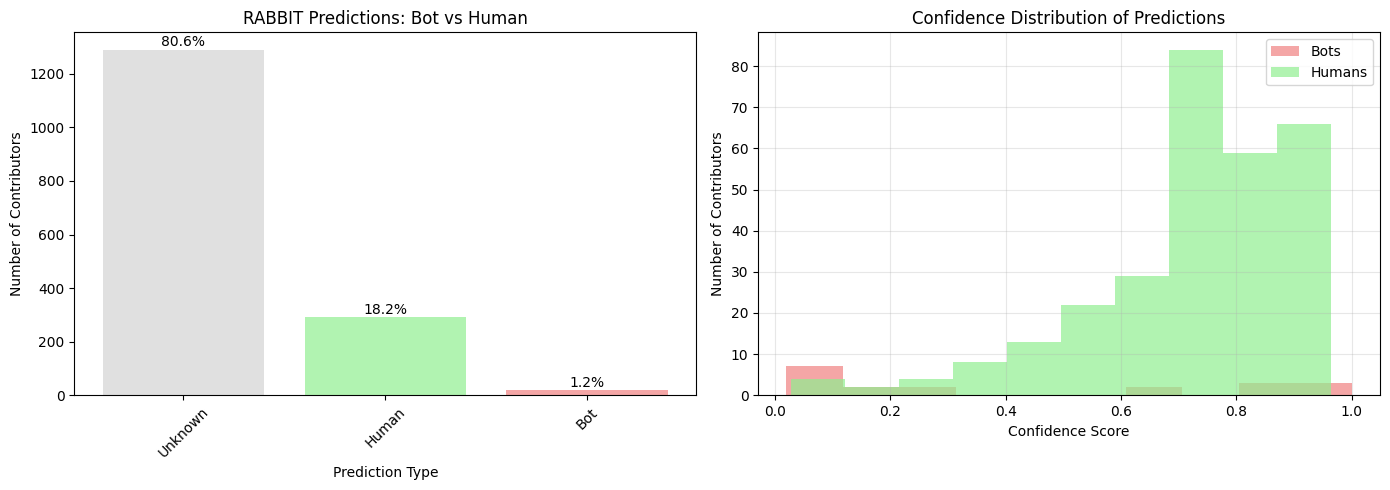

In [28]:
# Set up the visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Prediction type distribution
type_counts = rabbit_predictions['rabbit_type'].value_counts()
colors = {'Bot': 'lightcoral', 'Human': 'lightgreen', 'Unknown': 'lightgray', 'Error': 'orange'}
type_colors = [colors.get(t, 'gray') for t in type_counts.index]

axes[0].bar(type_counts.index, type_counts.values, color=type_colors, alpha=0.7)
axes[0].set_title('RABBIT Predictions: Bot vs Human')
axes[0].set_xlabel('Prediction Type')
axes[0].set_ylabel('Number of Contributors')
axes[0].tick_params(axis='x', rotation=45)

# Add percentage labels on bars
for i, (index, value) in enumerate(type_counts.items()):
    percentage = (value / len(rabbit_predictions) * 100)
    axes[0].text(i, value + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Plot 2: Confidence distribution for Bot predictions
if 'confidence' in rabbit_predictions.columns:
    bot_predictions = rabbit_predictions[rabbit_predictions['rabbit_type'] == 'Bot']
    human_predictions = rabbit_predictions[rabbit_predictions['rabbit_type'] == 'Human']
    
    if not bot_predictions.empty:
        axes[1].hist(bot_predictions['confidence'], bins=10, alpha=0.7, color='lightcoral', label='Bots')
    if not human_predictions.empty:
        axes[1].hist(human_predictions['confidence'], bins=10, alpha=0.7, color='lightgreen', label='Humans')
    
    axes[1].set_title('Confidence Distribution of Predictions')
    axes[1].set_xlabel('Confidence Score')
    axes[1].set_ylabel('Number of Contributors')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Question 2.3:**  
Look at the confidence distribution plot. Do bots tend to have higher confidence scores than humans? What might this indicate about the model's ability to identify bots?

*Your answer here.* En regardant la  deuxième graphique ("Confidence Distribution of Predictions"), on remarque deux comportements distincts :

Pour les Humains (en vert) : La majorité des scores se situe entre 0.7 et 0.9. Il y a une grande concentration de contributeurs dans cette zone, ce qui montre que le modèle reconnaît bien les schémas humains, mais avec une certaine nuance.

Pour les Bots (en rouge) : On observe deux pics. Un petit groupe a une confiance très faible (proche de 0), mais un autre groupe se situe à 1.0 (confiance maximale).        

*Your answer here.* Est-ce que les bots ont des scores plus élevés ?

Pas nécessairement en moyenne, mais ils sont plus "tranchés". * Les scores de confiance à 1.0 pour les bots proviennent souvent de l'heuristique du nom (les comptes finissant par [bot]). Pour ces cas, le modèle est certain à 100%.

Pour les bots détectés par le comportement (Machine Learning), les scores peuvent être plus variés.

Cette distribution indique plusieurs points sur la performance de RABBIT :

Capacité de Distinction : Le modèle sépare assez bien les deux populations. Le fait que les humains soient regroupés vers le haut (0.8) suggère que leurs séquences d'événements sont cohérentes et prévisibles pour l'IA.

La zone de doute (0.4 - 0.6) : Le faible nombre de contributeurs dans cette zone centrale montre que le modèle "hésite" rarement. Il finit souvent par classer l'individu d'un côté ou de l'autre avec une conviction raisonnable.

Limitation (Les "Inconnus") : Ton premier graphique montre que 80,6% des contributeurs sont "Inconnus". Cela indique que la plus grande limite du modèle n'est pas sa précision, mais sa sensibilité : il refuse de se prononcer si l'utilisateur n'a pas assez d'activité (moins de 5 événements), ce qui est une approche prudente pour éviter les faux positifs.

### 2.3. Manual Validation: Inspecting Bot & Human Profiles


Machine learning models are not perfect and their predictions can be uncertain. To better understand the limitations of RABBIT, we will manually inspect the contributors for which the model is **least confident**, i.e., those with the lowest confidence scores among bots and humans. These ambiguous cases are the most interesting for manual validation, as they may reveal edge cases or misclassifications.

The function below selects the `n_samples` bots and `n_samples` humans (for the analysis KEEP n_samples = 5) with the **lowest confidence** (excluding `'Unknown'` and `'Error'`). You will then examine their GitHub profiles and activities to decide whether you agree with RABBIT.

In [ ]:
def select_low_confidence_samples(predictions_df, n_samples=5):
    """
    Select the n_samples bots and n_samples humans with the lowest confidence scores
    for manual inspection. Excludes Unknown and Error types.
    
    Returns:
        DataFrame with up to 2*n_samples rows.
    """
    # Filter out Unknown and Error
    valid = predictions_df[predictions_df['rabbit_type'].isin(['Bot', 'Human'])]
    
    # Separate by type
    bots = valid[valid['rabbit_type'] == 'Bot'].nsmallest(n_samples, 'confidence')
    humans = valid[valid['rabbit_type'] == 'Human'].nsmallest(n_samples, 'confidence')
    
    # Combine and return
    samples = pd.concat([bots, humans], ignore_index=True)
    return samples

# Select low‑confidence bots and humans for manual inspection
low_conf_samples = select_low_confidence_samples(rabbit_predictions, n_samples=3)
print("👁️ LOW‑CONFIDENCE CONTRIBUTORS FOR MANUAL INSPECTION")
print("(These are the predictions where RABBIT is most uncertain.)")
print("-" * 60)
display(low_conf_samples)

Now, for each selected contributor, we will manually check their GitHub profile and recent activity. Use the generated guide below.

In [ ]:
def generate_inspection_guide(contributor_name, rabbit_type, confidence):
    """
    Generate guidelines for manually inspecting a contributor.
    """
    print(f"\n🔍 MANUAL INSPECTION: {contributor_name}")
    print(f"   RABBIT Prediction: {rabbit_type} (confidence: {confidence:.3f})")
    print("-" * 50)
    
    print("1️⃣ OPEN THEIR GITHUB PROFILE:")
    print(f"   https://github.com/{contributor_name}")
    print("   Look for:")
    print("   - Bio/description")
    print("   - Organisation affiliations")
    print("   - Website links")
    print("   - [bot] in username?")
    
    print("\n2️⃣ CHECK THEIR RECENT ACTIVITY:")
    print(f"   https://github.com/{contributor_name}?tab=activity")
    print("   Look for patterns:")
    print("   - Regular, automated-looking activities")
    print("   - Human-like comments and interactions")
    print("   - Type of repositories they contribute to")
    
    print("\n3️⃣ EXAMINE THEIR EVENTS IN OUR DATASET:")
    print("   Load their event data and look for:")
    print("   - Repetitive patterns")
    print("   - Timing of activities (same time daily?)")
    print("   - Types of actions (only commits? only comments?)")
    
    print("\n4️⃣ DECIDE: BOT or HUMAN?")
    print("   Based on your inspection, would you agree with RABBIT?")
    print("   Why or why not?")
    print("-" * 50)

# Generate inspection guides for sample contributors
for _, row in low_conf_samples.iterrows():
    generate_inspection_guide(row['contributor'], row['rabbit_type'], row['confidence'])

**TODO 2.4:** Create a DataFrame called `manual_validation` with columns: `contributor`, `rabbit_prediction`, `manual_assessment`, `agreement`, `evidence`. Then, for each contributor you inspected, fill in your findings.

In [ ]:
# TODO: Create and fill the manual validation DataFrame
manual_validation = pd.DataFrame(columns=[
    'contributor', 'rabbit_prediction', 'manual_assessment', 'agreement', 'evidence'
])

# Example (you will replace with actual data):
# manual_validation.loc[0] = ['dependabot[bot]', 'Bot', 'Bot', 'Yes', 'Username ends with [bot], auto comments on PRs']

display(manual_validation)

**Question 2.4:**  
Based on your manual inspection, how accurate do you think RABBIT is? Were there any surprises (e.g., a low‑confidence human that looked like a bot)? Explain.

*Your answer here.*

###  2.4. Merging Bot Predictions with Project Data

Now we combine the RABBIT predictions with the project event DataFrames we created in Section 1. This will allow us to analyse bot vs. human activity within each project.

In [29]:
def merge_predictions_with_projects(rabbit_predictions, project_dfs):
    """
    Merge RABBIT predictions with project event data.
    
    Args:
        rabbit_predictions: DataFrame with RABBIT predictions
        project_dfs: Dictionary of project DataFrames
        
    Returns:
        Dictionary of merged DataFrames for each project
    """
    merged_data = {}
    
    for project_name, project_df in project_dfs.items():
        # Extract unique contributors from this project
        project_contributors = project_df['actor.login'].unique()
        
        # Filter RABBIT predictions for contributors in this project
        project_predictions = rabbit_predictions[
            rabbit_predictions['contributor'].isin(project_contributors)
        ].copy()
        
        print(f"\n📊 Project: {project_name}")
        print(f"  Unique contributors in project: {len(project_contributors)}")
        print(f"  Contributors with RABBIT predictions: {len(project_predictions)}")
        
        if not project_predictions.empty:
            # Add prediction information to project events
            prediction_dict = project_predictions.set_index('contributor').to_dict(orient='index')
            
            # Create new columns in project DataFrame
            project_df['rabbit_type'] = project_df['actor.login'].map(
                lambda x: prediction_dict.get(x, {}).get('rabbit_type', 'Unknown')
            )
            project_df['rabbit_confidence'] = project_df['actor.login'].map(
                lambda x: prediction_dict.get(x, {}).get('confidence', 0.0)
            )
            
            merged_data[project_name] = project_df
            
            # Summary
            bot_count = (project_df['rabbit_type'] == 'Bot').sum()
            human_count = (project_df['rabbit_type'] == 'Human').sum()
            unknown_count = (project_df['rabbit_type'] == 'Unknown').sum()
            
            print(f"  Bot events: {bot_count}")
            print(f"  Human events: {human_count}")
            print(f"  Unknown events: {unknown_count}")
        
    return merged_data

# Merge predictions with projects
merged_projects = merge_predictions_with_projects(rabbit_predictions, project_dfs)


📊 Project: cupy_cupy
  Unique contributors in project: 1498
  Contributors with RABBIT predictions: 1498
  Bot events: 95
  Human events: 1535
  Unknown events: 1276

📊 Project: lfortran_lfortran
  Unique contributors in project: 102
  Contributors with RABBIT predictions: 102
  Bot events: 75
  Human events: 6279
  Unknown events: 49


In [30]:
# Display a sample of merged data
if merged_projects:
    first_project = list(merged_projects.keys())[0]
    print(f"\n📋 Sample of merged data for {first_project}:")
    display(merged_projects[first_project][['actor.login', 'type', 'rabbit_type', 'rabbit_confidence']].head(10))


📋 Sample of merged data for cupy_cupy:


,actor.login,type,rabbit_type,rabbit_confidence
0,fbender,WatchEvent,Unknown,NaN
1,mrakgr,IssuesEvent,Bot,0.045
2,kmaehashi,IssueCommentEvent,Human,0.856
3,deftlion,WatchEvent,Human,0.772
4,HarshilShah1804,ForkEvent,Human,0.854
5,kmaehashi,IssueCommentEvent,Human,0.856
6,kmaehashi,PullRequestEvent,Human,0.856
7,Robotics-jw,WatchEvent,Unknown,NaN
8,fortheD,WatchEvent,Unknown,NaN
9,kmaehashi,IssueCommentEvent,Human,0.856


**Question 2.5:**  
Look at the bot event percentages for each project. Which project has a higher proportion of bot activity? Does this match your expectation from Section 1? Why might one project rely more on bots?

*Your answer here.*  1)  Lequel a la plus haute proportion d'activité bot ?
C'est le projet CuPy (3,3 %) qui présente une proportion d'activité automatisée plus élevée que LFortran (1,2 %), même si dans les deux cas, l'activité humaine reste largement dominante.

2) Est-ce que cela correspond à mes attentes de la Section 1 ?

Oui, cela confirme mes  observations de la Section 1.4 où j'avais repéré des comptes comme chainer-ci ou fusionner [bot] dans le Top 15 des contributeurs les plus actifs de CuPy.

Dans les graphiques de la Section 1, CuPy montrait également une forte proportion d'événements de type "Dépôt" (WatchEvent/ForkEvent), qui sont souvent le signe d'une surveillance automatisée ou d'outils de miroir.

3) Pourquoi un projet s'appuie-t-il plus sur les bots ?
Il existe plusieurs raisons techniques pour lesquelles CuPy (projet lié à l'écosystème NVIDIA/CUDA) utilise plus d'automates :

Intégration Continue (CI/CD) complexe : Les projets de calcul haute performance nécessitent des tests sur des hardwares spécifiques (GPU). Les bots comme chainer-ci gèrent ces tests automatiquement.

Gestion des dépendances : Des bots peuvent être utilisés pour synchroniser les versions entre CuPy et d'autres bibliothèques.

Taille de la communauté : CuPy a beaucoup plus de contributeurs uniques (1498 contre 102 pour LFortran). Plus un projet est grand, plus il a besoin de bots pour trier les "Issues" et valider les "Pull Requests" afin de décharger les mainteneurs humains.

Finally, we compare the types of activities performed by bots and humans in each project.

In [31]:
def analyse_bot_vs_human_activity(merged_project_df, project_name):
    """
    Compare activity patterns between bots and humans.
    """
    print(f"\n🔬 BOT VS HUMAN ANALYSIS: {project_name}")
    print("-" * 50)
    
    # Separate bot and human events
    bot_events = merged_project_df[merged_project_df['rabbit_type'] == 'Bot']
    human_events = merged_project_df[merged_project_df['rabbit_type'] == 'Human']
    
    print(f"Total events: {len(merged_project_df)}")
    print(f"Bot events: {len(bot_events)} ({len(bot_events)/len(merged_project_df)*100:.1f}%)")
    print(f"Human events: {len(human_events)} ({len(human_events)/len(merged_project_df)*100:.1f}%)")
    
    # Event type distribution comparison
    if not bot_events.empty:
        bot_event_types = bot_events['event_category'].value_counts()
        print(f"\n📊 Bot Event Categories:")
        for category, count in bot_event_types.items():
            percentage = (count / len(bot_events) * 100)
            print(f"  {category}: {count} events ({percentage:.1f}%)")
    
    if not human_events.empty:
        human_event_types = human_events['event_category'].value_counts()
        print(f"\n📊 Human Event Categories:")
        for category, count in human_event_types.items():
            percentage = (count / len(human_events) * 100)
            print(f"  {category}: {count} events ({percentage:.1f}%)")
    
    # Time analysis
    if not bot_events.empty and not human_events.empty:
        print(f"\n⏰ Activity Timing:")
        print(f"  Bot activity period: {bot_events['created_at'].min().date()} to {bot_events['created_at'].max().date()}")
        print(f"  Human activity period: {human_events['created_at'].min().date()} to {human_events['created_at'].max().date()}")
    
    return bot_events, human_events

# Analyse each project
for project_name, project_df in merged_projects.items():
    bot_events, human_events = analyse_bot_vs_human_activity(project_df, project_name)


🔬 BOT VS HUMAN ANALYSIS: cupy_cupy
--------------------------------------------------
Total events: 2906
Bot events: 95 (3.3%)
Human events: 1535 (52.8%)

📊 Bot Event Categories:
  Issues: 56 events (58.9%)
  Pull Requests: 32 events (33.7%)
  Repository: 7 events (7.4%)

📊 Human Event Categories:
  Pull Requests: 657 events (42.8%)
  Issues: 563 events (36.7%)
  Repository: 211 events (13.7%)
  Commits: 100 events (6.5%)
  Other: 4 events (0.3%)

⏰ Activity Timing:
  Bot activity period: 2024-09-09 to 2024-11-30
  Human activity period: 2024-09-02 to 2024-11-30

🔬 BOT VS HUMAN ANALYSIS: lfortran_lfortran
--------------------------------------------------
Total events: 6403
Bot events: 75 (1.2%)
Human events: 6279 (98.1%)

📊 Bot Event Categories:
  Issues: 68 events (90.7%)
  Repository: 4 events (5.3%)
  Pull Requests: 3 events (4.0%)

📊 Human Event Categories:
  Pull Requests: 3738 events (59.5%)
  Issues: 2077 events (33.1%)
  Commits: 413 events (6.6%)
  Repository: 51 events (0.8

Now, let's visualise the differences for the first project.

/var/folders/0k/b78xhb6x78ld0v6p486hcq200000gn/T/ipykernel_30943/2030213354.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_to_plot, labels=labels)
/var/folders/0k/b78xhb6x78ld0v6p486hcq200000gn/T/ipykernel_30943/2030213354.py:99: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/abdelouahad/TP3_Analyser_Activit-_robots_et_humains/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


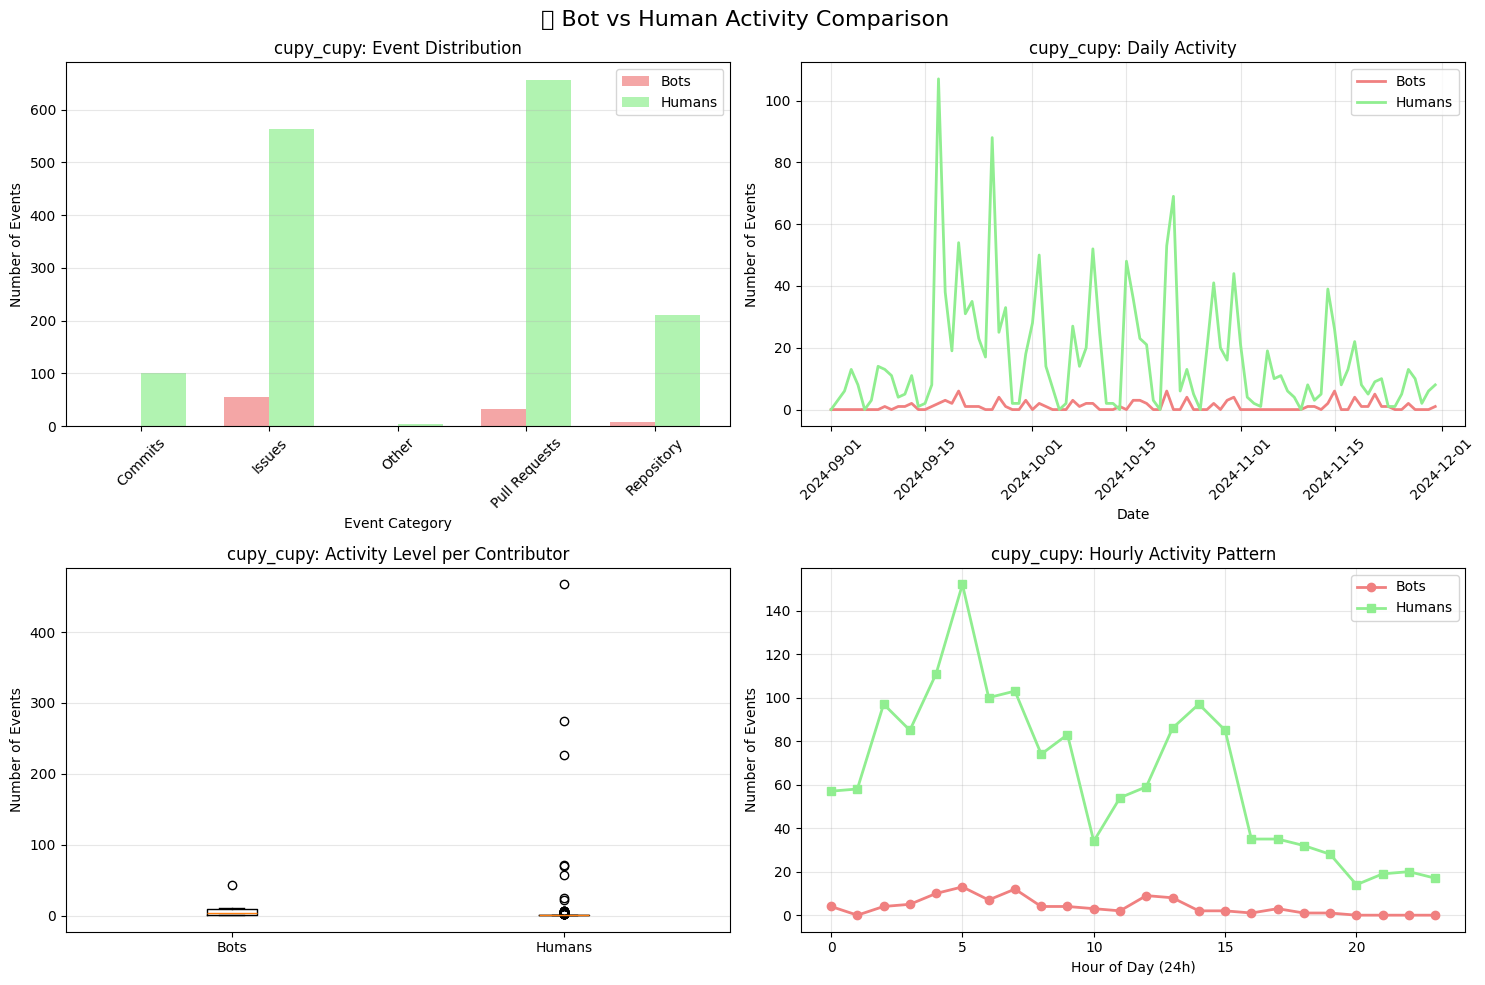

In [32]:
# Set up comparison visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🤖 Bot vs Human Activity Comparison', fontsize=16)

# Plot 1: Event category comparison for Project 1
project1_name = list(merged_projects.keys())[0]
project1_df = merged_projects[project1_name]

if not project1_df.empty:
    # Get category distribution for bots and humans
    bot_categories = project1_df[project1_df['rabbit_type'] == 'Bot']['event_category'].value_counts()
    human_categories = project1_df[project1_df['rabbit_type'] == 'Human']['event_category'].value_counts()
    
    # Create combined DataFrame for comparison
    categories = sorted(set(bot_categories.index) | set(human_categories.index))
    comparison_data = []
    
    for category in categories:
        comparison_data.append({
            'Category': category,
            'Bot': bot_categories.get(category, 0),
            'Human': human_categories.get(category, 0)
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Plot grouped bar chart
    x = np.arange(len(comparison_df))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, comparison_df['Bot'], width, label='Bots', color='lightcoral', alpha=0.7)
    axes[0, 0].bar(x + width/2, comparison_df['Human'], width, label='Humans', color='lightgreen', alpha=0.7)
    
    axes[0, 0].set_xlabel('Event Category')
    axes[0, 0].set_ylabel('Number of Events')
    axes[0, 0].set_title(f'{project1_name}: Event Distribution')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(comparison_df['Category'], rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Daily activity comparison
if not project1_df.empty:
    # Group by date and type
    project1_df['date'] = project1_df['created_at'].dt.date
    daily_activity = project1_df.groupby(['date', 'rabbit_type']).size().unstack(fill_value=0)
    
    if 'Bot' in daily_activity.columns and 'Human' in daily_activity.columns:
        axes[0, 1].plot(daily_activity.index, daily_activity['Bot'], label='Bots', color='lightcoral', linewidth=2)
        axes[0, 1].plot(daily_activity.index, daily_activity['Human'], label='Humans', color='lightgreen', linewidth=2)
        axes[0, 1].set_xlabel('Date')
        axes[0, 1].set_ylabel('Number of Events')
        axes[0, 1].set_title(f'{project1_name}: Daily Activity')
        axes[0, 1].legend()
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Contributor activity levels
if not project1_df.empty:
    # Calculate events per contributor
    contributor_activity = project1_df.groupby(['actor.login', 'rabbit_type']).size().reset_index(name='event_count')
    
    # Separate bots and humans
    bot_contributors = contributor_activity[contributor_activity['rabbit_type'] == 'Bot']
    human_contributors = contributor_activity[contributor_activity['rabbit_type'] == 'Human']
    
    # Create box plot
    data_to_plot = []
    labels = []
    
    if not bot_contributors.empty:
        data_to_plot.append(bot_contributors['event_count'].values)
        labels.append('Bots')
    
    if not human_contributors.empty:
        data_to_plot.append(human_contributors['event_count'].values)
        labels.append('Humans')
    
    if data_to_plot:
        axes[1, 0].boxplot(data_to_plot, labels=labels)
        axes[1, 0].set_ylabel('Number of Events')
        axes[1, 0].set_title(f'{project1_name}: Activity Level per Contributor')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Hourly activity patterns
if not project1_df.empty:
    project1_df['hour'] = project1_df['created_at'].dt.hour
    hourly_activity = project1_df.groupby(['hour', 'rabbit_type']).size().unstack(fill_value=0)
    
    if 'Bot' in hourly_activity.columns and 'Human' in hourly_activity.columns:
        axes[1, 1].plot(hourly_activity.index, hourly_activity['Bot'], label='Bots', color='lightcoral', linewidth=2, marker='o')
        axes[1, 1].plot(hourly_activity.index, hourly_activity['Human'], label='Humans', color='lightgreen', linewidth=2, marker='s')
        axes[1, 1].set_xlabel('Hour of Day (24h)')
        axes[1, 1].set_ylabel('Number of Events')
        axes[1, 1].set_title(f'{project1_name}: Hourly Activity Pattern')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Question 2.6:**  
Based on the bar chart, which event categories are dominated by bots? Which are mostly human? What does this tell you about the typical tasks that bots automate in this project?

*Your answer here.* Analyse: Comparaison Humains vs Robots

En observant le diagramme en barres (Event Distribution) et les statistiques générées par le code, on peut tirer les conclusions suivantes :

1. Quelles catégories sont dominées par les bots ?

Même si les humains font plus de volume partout, on voit que les bots se concentrent presque exclusivement sur deux types de tâches :

Les Issues: C'est leur activité principale. Sur CuPy, ils font 58.9% de leurs actions ici. Sur LFortran, c'est encore plus frappant avec 90.7%.

Les Pull Requests (Demandes de tirage) : Ils interviennent aussi pour commenter ou valider des changements (environ 33.7% de leur activité sur CuPy).

2. Quelles catégories sont purement humaines ?

Les Commits (Enregistrements de code) : C'est le point le plus important. Les bots ont 0% d'activité en "Commits" dans les deux projets.

Le Dépôt (Watch/Fork) : Les actions de "mise en favoris" ou de copie du projet sont quasi exclusivement le fait des humains (comme on le voit avec les grandes barres vertes dans le graphique de distribution).

3. Qu'est-ce que cela nous dit sur le rôle des bots ?

Cette répartition montre que les bots ne sont pas là pour "créer" du contenu (puisqu'ils ne font pas de commits), mais pour gérer le flux de travail :

Automatisation administrative : Ils servent de "secrétaires" pour trier les tickets (Issues) ou fermer ceux qui sont inactifs.

Assistance technique : Dans les Pull Requests, ils agissent comme des outils de vérification (CI/CD) qui testent le code envoyé par les humains avant qu'un humain ne décide de l'accepter.

Disponibilité constante : Le graphique Hourly Activity Pattern montre que les bots (ligne rouge) gardent une activité stable et plate toute la journée, alors que les humains (ligne verte) ont des pics et des creux selon leurs heures de bureau ou de sommeil.

## Section 3: Contributor Role Categorisation

In Section 2, we identified which contributors are bots using RABBIT. Now we will go a step further and examine **what** these contributors actually do in the project. By analysing their activities, we can assign them behavioral roles such as *developer*, *reviewer*, *reporter*, etc. This will allow us to compare bots and humans at a much finer granularity: do bots tend to specialise in certain roles? Are humans more diverse? How does the distribution of roles differ between the two projects?

### 3.1. Defining Roles from Project-Events

The roles we use are based on established software engineering research. They are defined as follows:

| **_Role_**    | **_Description_**                                                               |
|---------------|---------------------------------------------------------------------------------|
| **developer** | Pushed commits, opened a pull request or commented on their own pull request   |
| **reviewer**  | Reviewed a pull request or commented on a pull request review (by someone else) |
| **merger**    | Merged a pull request                                                           |
| **reporter**  | Opened an issue or commented on their own issue                                 |
| **commenter** | Commented on an issue opened by someone else                                    |
| **reactor**   | Reacted to content (requires additional API data, not available in our dataset) |

These roles are **not mutually exclusive**: a contributor can be both a developer and a reviewer in the same project and the counts for each role accumulate over time. For example, if a contributor opens 3 pull requests and reviews 2 pull requests, they will have `developer = 3` and `reviewer = 2`.

The input data for this analysis are the **activity sequences** stored in the `Project-Activities/` folder. Each line in these `.jsonl` files represents a single *activity*, a higher‑level abstraction of GitHub events (e.g., `OpenIssue`, `ReviewPullRequest`). The activities are already enriched with context (e.g., whether a comment was on one’s own issue or someone else’s), which enables the role assignment logic.

> 📁 **Data location**: `DATA_BASE_PATH / 'Project-Activities'` (the same base path you set in Section 1 & 2).

First, let's locate the activity files and load them into DataFrames.

In [33]:
ACTIVITIES_PATH = DATA_BASE_PATH / 'Project-Activities'

# List the activity files
activity_files = list(ACTIVITIES_PATH.glob('*.jsonl'))
print(f"📂 Found {len(activity_files)} activity files:")
for f in activity_files:
    print(f"  - {f.name}")

📂 Found 2 activity files:
  - cupy_cupy.jsonl
  - lfortran_lfortran.jsonl


Now load each file. The files are in **JSON Lines** format, each line is a separate JSON object. We use `pd.read_json(..., lines=True)` to read them directly.

In [34]:
# Load activities for each project into a dictionary
activities_dfs = {}
for file in activity_files:
    project_name = file.stem  # e.g., 'cupy_cupy'
    df = pd.read_json(file, lines=True)
    activities_dfs[project_name] = df
    print(f"\n✅ Loaded {len(df)} activities for {project_name}")
    print(f"   Sample columns: {list(df.columns)}")


✅ Loaded 2472 activities for cupy_cupy
   Sample columns: ['activity', 'start_date', 'end_date', 'actor', 'repository', 'actions']

✅ Loaded 4325 activities for lfortran_lfortran
   Sample columns: ['activity', 'start_date', 'end_date', 'actor', 'repository', 'actions']


**TODO 3.1:** In the cell below, write a short loop to display the **first 2 rows** of the activity DataFrame for one of the projects. This will help you see the structure of an activity record.

In [36]:
# Affichage des 2 premières lignes pour le projet CuPy
project_name = 'cupy_cupy'
print(f"Aperçu des activités pour {project_name} :")
display(activities_dfs[project_name].head(2))

🔍 Aperçu des activités pour cupy_cupy :


,activity,start_date,end_date,actor,repository,actions
0,StarRepository,2024-09-01T00:24:36Z,2024-09-01T00:24:36Z,"{'id': 44755534, 'login': 'louisprimeau'}","{'id': 72523920, 'name': 'cupy/cupy', 'organis...","[{'action': 'StarRepository', 'event_id': '415..."
1,ForkRepository,2024-09-01T02:38:00Z,2024-09-01T02:38:00Z,"{'id': 68695780, 'login': 'Maki4748'}","{'id': 72523920, 'name': 'cupy/cupy', 'organis...","[{'action': 'ForkRepository', 'event_id': '415..."


**Question 3.1:**  
Look at the columns of the activity DataFrame. What information does each activity contain? Why is it important that the `actor` and `repository` are stored as dictionaries rather than simple strings?

*Your answer here.* 1. Quelles informations contient chaque activité ?

D'après l'aperçu du DataFrame cupy_cupy, chaque ligne représente une action logique et contient :

activity : Le type d'action effectuée (ex: StarRepository, ForkRepository).

start_date et end_date : L'horodatage précis du début et de la fin de l'action.

actor : Un dictionnaire contenant l'identifiant numérique (id) et le nom d'utilisateur (login) de la personne.

repository : Un dictionnaire avec l'ID et le nom complet du projet concerné.

actions : Une liste (ici un dictionnaire imbriqué) qui détaille l'événement brut GitHub à l'origine de cette activité.

2. Pourquoi utiliser des dictionnaires pour actor et repository ?

Il est très important de stocker ces données sous forme de dictionnaires plutôt que de simples chaînes de caractères pour plusieurs raisons :

Unicité des données : Le nom d'utilisateur (login) peut changer, mais l'identifiant numérique (id) reste fixe. En stockant le dictionnaire complet, on garde un lien permanent et unique avec le compte de l'utilisateur.

Richesse de l'information : Cela permet de regrouper plusieurs informations liées dans une seule colonne. Par exemple, pour le dépôt, on a à la fois son nom et son ID interne sans avoir besoin de créer 10 colonnes différentes.

Structure hiérarchique : Comme ces données proviennent de fichiers JSON, garder la structure de dictionnaire permet de manipuler les données plus facilement avec Python (on peut accéder à l'ID en faisant simplement actor['id']) sans perdre de détails lors du chargement.

### 3.2. Assigning Roles: Developer, Reviewer, Reporter, etc.

We will now use the `roles` module (provided in the repository) to assign role counts to every contributor. The function `roles.assign()` expects a DataFrame with the same structure as the ones we just loaded and returns a new DataFrame with one row per contributor and columns for each role count.

In [37]:
# Import the role assignment module
import roles

role_dfs = {}

for project_name, df_act in activities_dfs.items():
    print(f"\n🔧 Assigning roles for {project_name} ...")

    df_roles = roles.assign(df_act)

    role_dfs[project_name] = df_roles
    print(f"   Found {len(df_roles)} distinct contributors.")
    print(f"   Role counts (sum over all contributors):")
    role_sums = df_roles[['developer','reviewer','merger','reporter','commenter','reactor']].sum()
    print(role_sums.to_string())


🔧 Assigning roles for cupy_cupy ...
   Found 1498 distinct contributors.
   Role counts (sum over all contributors):
developer    195
reviewer     189
merger       101
reporter     114
commenter    117
reactor        0

🔧 Assigning roles for lfortran_lfortran ...
   Found 102 distinct contributors.
   Role counts (sum over all contributors):
developer    1034
reviewer      917
merger        399
reporter      470
commenter     391
reactor         0


**TODO 3.2:** After running the cell above, compute the **average number of developer actions per contributor** for each project. Use the `role_dfs` dictionary. Print the results.

In [38]:
for project_name, df_roles in role_dfs.items():
    avg_dev = df_roles['developer'].mean()
    print(f"{project_name}: Average developer actions per contributor = {avg_dev:.2f}")

cupy_cupy: Average developer actions per contributor = 0.13
lfortran_lfortran: Average developer actions per contributor = 10.14


Les moyennes calculées montrent deux réalités très différentes pour ces projets open-source :

CuPy (0.13 actions/contributeur) : Cette moyenne très faible indique que la grande majorité des 1498 contributeurs ne participe pas du tout au développement du code. C'est un projet avec une immense base d'utilisateurs qui "observent" ou utilisent la bibliothèque sans forcément soumettre de modifications.

LFortran (10.14 actions/contributeur) : Ici, la moyenne est presque 80 fois supérieure à celle de CuPy. Cela prouve que les 102 contributeurs de LFortran sont des développeurs extrêmement actifs et impliqués.

**Question 3.2:**  
Look at the role totals printed above. Which role has the highest total count in each project? Which role has the lowest? What might this tell you about the development workflow of each project?

*Your answer here.* En observant les totaux des rôles pour chaque projet, on peut déduire les éléments suivants sur leur workflow (flux de travail) :

1. Rôles dominants et faibles

Rôle le plus élevé : Pour les deux projets, il s'agit du rôle developer (195 pour CuPy, 1034 pour LFortran). Cela montre que l'activité principale enregistrée reste la création ou la modification de code.

Rôle le plus bas : Pour CuPy, c'est le rôle merger (101), ce qui est logique car seule une petite élite a le droit de valider et fusionner le code. Pour LFortran, c'est le rôle commenter (391).

Le cas reactor : Le score est de 0 partout car, comme indiqué dans l'énoncé, cette donnée n'est pas disponible dans notre dataset actuel.

2. Ce que cela révèle sur le fonctionnement des projets

LFortran : Un noyau dur d'experts. Le nombre élevé de reviewer (917) et de merger (399) par rapport au petit nombre de contributeurs (102) indique un workflow très collaboratif. Les membres de l'équipe ne se contentent pas de coder ; ils passent énormément de temps à relire et à valider le travail des autres.

CuPy : Une structure pyramidale. Le faible nombre d'actions par personne suggère que le projet repose sur une multitude d'utilisateurs passifs et un groupe très restreint de développeurs qui gèrent les Pull Requests et les Issues. C'est un workflow typique des très grandes bibliothèques populaires.

### 3.3. Visualising Role Distributions per Project

Now we visualise how roles are distributed. First, we look at **role presence**: how many contributors performed each role at least once.

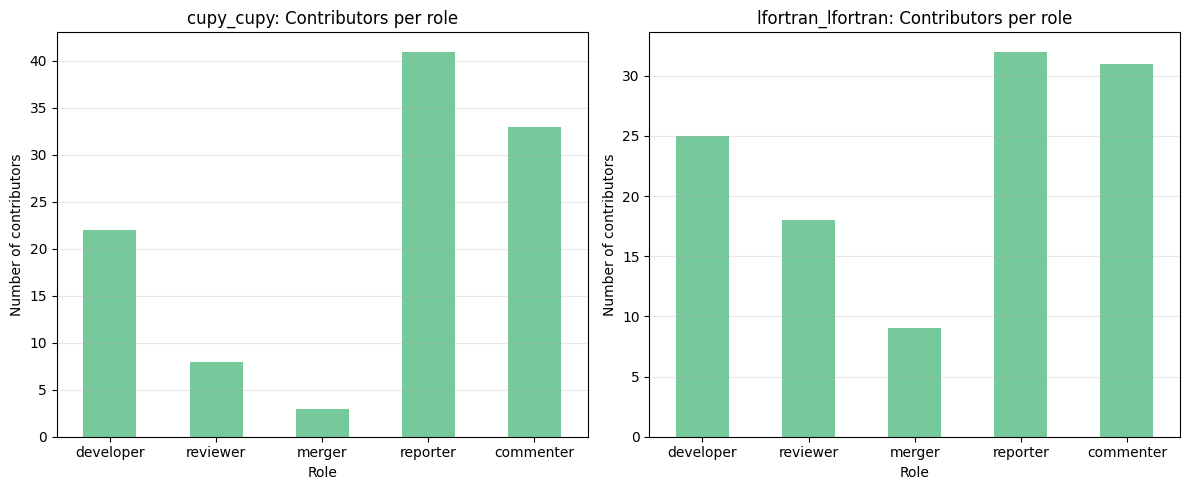

In [39]:
def plot_role_presence(role_df, project_name, ax):
    """Plot the number of contributors who have at least one occurrence of each role."""
    # Count non-zero entries for each role
    presence = (role_df[['developer','reviewer','merger','reporter','commenter']] > 0).sum()
    
    presence.plot(kind='bar', ax=ax, color='mediumseagreen', alpha=0.7)
    ax.set_title(f'{project_name}: Contributors per role')
    ax.set_ylabel('Number of contributors')
    ax.set_xlabel('Role')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (proj, df_roles) in enumerate(role_dfs.items()):
    plot_role_presence(df_roles, proj, axes[i])
plt.tight_layout()
plt.show()

Second, we look at **role intensity**: the total number of activities for each role (summed over all contributors).

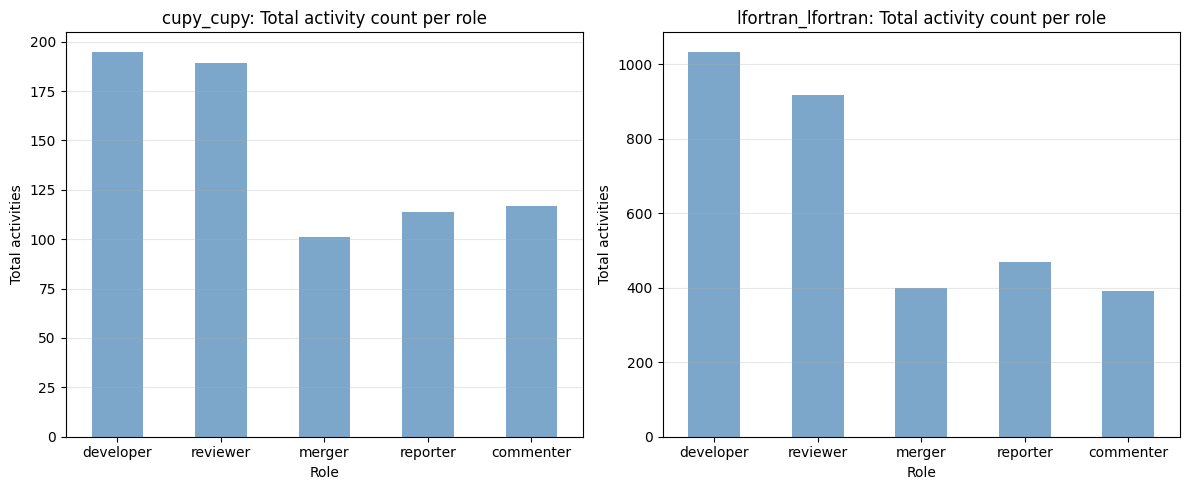

In [40]:
def plot_role_intensity(role_df, project_name, ax):
    """Plot the total number of role-related activities (sum over all contributors)."""
    totals = role_df[['developer','reviewer','merger','reporter','commenter']].sum()
    
    totals.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{project_name}: Total activity count per role')
    ax.set_ylabel('Total activities')
    ax.set_xlabel('Role')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (proj, df_roles) in enumerate(role_dfs.items()):
    plot_role_intensity(df_roles, proj, axes[i])
plt.tight_layout()
plt.show()

**Question 3.3:**  
Compare the two plots for each project. Are there roles that have many contributors but relatively few total activities? What about roles with few contributors but many activities? What might explain these patterns (e.g., some roles are performed occasionally by many, others intensively by a few)?

*Your answer here.* Analyse : Présence vs Intensité

En comparant le nombre de contributeurs par rôle et le nombre total d'activités, on observe des schémas très clairs :

1. Rôles à forte présence mais faible intensité relative (Rôles "occasionnels")

Observations : Dans le projet CuPy, le rôle de Journaliste (Reporter) et de Commentateur affiche les barres vertes les plus hautes (plus de 30-40 contributeurs), mais leurs barres bleues en intensité restent modestes par rapport aux autres.

Explication : Ce sont des rôles accessibles à tous. Beaucoup d'utilisateurs ouvrent un ticket (issue) une seule fois pour signaler un bug ou posent une question en commentaire, puis ne reviennent plus. C'est une activité "horizontale" pratiquée par la masse.

2. Rôles à faible présence mais forte intensité (Rôles "experts")

Observations : Le rôle de Fusion (Merger) et de Critique (Reviewer) montre des barres vertes plus basses (surtout pour Merger dans CuPy, avec moins de 5 personnes), mais des barres bleues proportionnellement très élevées.

Explication : Ce sont des rôles "verticaux". Seul un petit groupe de mainteneurs de confiance a le droit de fusionner du code ou de réviser les Pull Requests. Ces quelques individus sont extrêmement actifs et répètent ces actions des centaines de fois.

3. Cas particulier de LFortran

Observations : Pour LFortran, les barres bleues (Intensité) sont gigantesques (plus de 1000 pour le rôle Révélateur/Developer) alors que le nombre de contributeurs (barres vertes) reste sous la barre des 35.

Analyse : Cela confirme que LFortran est porté par un noyau dur de développeurs ultra-intensifs. Chaque développeur effectue énormément d'actions de code, de revue et de fusion, contrairement à CuPy où l'activité est plus diluée parmi un grand nombre de personnes qui en font très peu individuellement.

### 3.4. Combining Roles with Bot/Human Labels

Now we combine the role data with the RABBIT predictions we obtained in Section 2. This will allow us to compare the behavior of bots and humans.

First, ensure that `rabbit_predictions` is available. If you need to reload it, uncomment the appropriate line.

In [41]:
# If Section 2 ran successfully, RABBIT predictions are already stored in `rabbit_predictions`.
# Otherwise, load them from DATA_BASE_PATH / 'User_Types.csv' (already prepared for you if needed).

print("🐇 RABBIT predictions preview:")
display(rabbit_predictions.head())

🐇 RABBIT predictions preview:


,contributor,rabbit_type,confidence,Events
0,01PrathamS,Unknown,NaN,1
1,0Z17,Unknown,NaN,1
2,0x-CHUN,Unknown,NaN,2
3,0xGeorgeTorres,Unknown,NaN,1
4,0xjavad,Unknown,NaN,1


Now merge each project's role DataFrame with the predictions.

In [42]:
# Merge role data with rabbit_type
role_with_labels = {}
for proj, df_roles in role_dfs.items():
    # Left join: keep all roles rows, add rabbit_type where available
    merged = df_roles.merge(rabbit_predictions[['contributor', 'rabbit_type', 'confidence']], 
                            on='contributor', how='left')
    # Fill missing rabbit_type with 'Unknown'
    merged['rabbit_type'] = merged['rabbit_type'].fillna('Unknown')
    role_with_labels[proj] = merged
    
    print(f"\n{proj}:")
    print(merged['rabbit_type'].value_counts(dropna=False))
    print(merged.head())


cupy_cupy:
rabbit_type
Unknown    1245
Human       240
Bot          13
Name: count, dtype: int64
      contributor    project  developer  reviewer  merger  reporter  \
0      01PrathamS  cupy/cupy          0         0       0         0   
1            0Z17  cupy/cupy          0         0       0         0   
2         0x-CHUN  cupy/cupy          0         0       0         0   
3  0xGeorgeTorres  cupy/cupy          0         0       0         0   
4         0xjavad  cupy/cupy          0         0       0         0   

   commenter  reactor rabbit_type  confidence  
0          0        0     Unknown         NaN  
1          0        0     Unknown         NaN  
2          0        0     Unknown         NaN  
3          0        0     Unknown         NaN  
4          0        0     Unknown         NaN  

lfortran_lfortran:
rabbit_type
Human      51
Unknown    45
Bot         6
Name: count, dtype: int64
       contributor            project  developer  reviewer  merger  reporter  \
0  Abhi

**TODO 3.3:** For the first project, calculate the **median** number of developer actions for bots and for humans separately. (Use `.median()` instead of `.mean()`.) Print both values.

In [43]:
# Calcul de la médiane pour le premier projet (CuPy)
project_name = list(role_with_labels.keys())[0]
df_p1 = role_with_labels[project_name]

median_bot = df_p1[df_p1['rabbit_type'] == 'Bot']['developer'].median()
median_human = df_p1[df_p1['rabbit_type'] == 'Human']['developer'].median()

print(f"📊 Projet: {project_name}")
print(f"  Médiane d'actions 'developer' pour les Bots: {median_bot}")
print(f"  Médiane d'actions 'developer' pour les Humains: {median_human}")

📊 Projet: cupy_cupy
  Médiane d'actions 'developer' pour les Bots: 0.0
  Médiane d'actions 'developer' pour les Humains: 0.0


Le fait que la médiane soit de 0.0 pour les deux groupes dans CuPy signifie que :

Plus de 50% des contributeurs (qu'ils soient identifiés comme humains ou bots) n'ont effectué aucune action de type "developer" (pas de commit, pas d'ouverture de Pull Request).

Cela confirme notre analyse précédente : CuPy est un projet "miroir" ou très populaire où la grande majorité des gens interagissent via d'autres rôles comme le signalement de bugs (Reporter) ou simplement l'observation (Star/Fork).

**Question 3.4:**  
Look at the value counts printed above. How many contributors in each project have an `'Unknown'` rabbit_type? Why are they unknown? (Hint: recall which contributors RABBIT analysed.)

*Your answer here.*  1. Constat quantitatif

Dans le projet cupy_cupy, on dénombre 1245 contributeurs 'Unknown'.

Dans le projet lfortran_lfortran, ils sont au nombre de 45.

2. Pourquoi sont-ils classés ainsi ?

Ces contributeurs sont marqués comme 'Unknown' car l'outil RABBIT nécessite une certaine quantité de données pour établir un profil comportemental fiable.

Faible activité : La plupart de ces utilisateurs n'ont qu'un seul événement enregistré (souvent un WatchEvent ou un ForkEvent). Avec une seule action.

Périmètre de l'analyse : RABBIT analyse les séquences d'activités. Si un utilisateur n'a pas de "séquence" (moins de 5 événements en général), le modèle préfère ne pas se prononcer plutôt que de donner une prédiction erronée.

3. Ce que cela implique pour le projet

Le nombre massif d'Unknown dans CuPy (1245 contre seulement 240 humains identifiés) montre que le projet attire énormément d'utilisateurs passifs ou ponctuels, contrairement à LFortran où la communauté semble plus active et donc plus facile à identifier .

We can now compare the average (mean) role counts for bots and humans. This tells us what a “typical” bot does versus a typical human.

In [44]:
def compare_bot_human_roles(merged_df, project_name):
    """Compute mean role counts for bots and humans."""
    grouped = merged_df.groupby('rabbit_type')[['developer','reviewer','merger','reporter','commenter']].mean()
    return grouped

for proj, df in role_with_labels.items():
    print(f"\n📊 {proj} - Average role activities per contributor type")
    display(compare_bot_human_roles(df, proj))


📊 cupy_cupy - Average role activities per contributor type


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,2.615385,0.0000,0.000000,1.307692,0.153846
Human,0.662500,0.7875,0.420833,0.308333,0.416667
Unknown,0.001606,0.0000,0.000000,0.018474,0.012048



📊 lfortran_lfortran - Average role activities per contributor type


,developer,reviewer,merger,reporter,commenter
rabbit_type,,,,,
Bot,0.500000,0.166667,0.000000,8.000000,2.333333
Human,20.196078,17.960784,7.823529,8.196078,7.313725
Unknown,0.022222,0.000000,0.000000,0.088889,0.088889


**TODO 3.4:** Write a few lines of code to extract the mean values for bots in the second project and print them in a formatted way (e.g., `"Developer: 2.6, Reviewer: 0.0, ..."`).

In [47]:
pwd

'/Users/abdelouahad/TP3_Analyser_Activit-_robots_et_humains'

In [46]:
# Extraction des moyennes pour les bots du deuxième projet (lfortran_lfortran)
proj2_name = list(role_with_labels.keys())[1]
bot_means = compare_bot_human_roles(role_with_labels[proj2_name], proj2_name).loc['Bot']

print(f"🤖 Moyennes d'activités pour les Bots dans {proj2_name}:")
print(f"Developer: {bot_means['developer']:.2f}, Reviewer: {bot_means['reviewer']:.2f}, "
      f"Merger: {bot_means['merger']:.2f}, Reporter: {bot_means['reporter']:.2f}, "
      f"Commenter: {bot_means['commenter']:.2f}")

🤖 Moyennes d'activités pour les Bots dans lfortran_lfortran:
Developer: 0.50, Reviewer: 0.17, Merger: 0.00, Reporter: 8.00, Commenter: 2.33


Now let's visualise these differences with grouped bar charts.

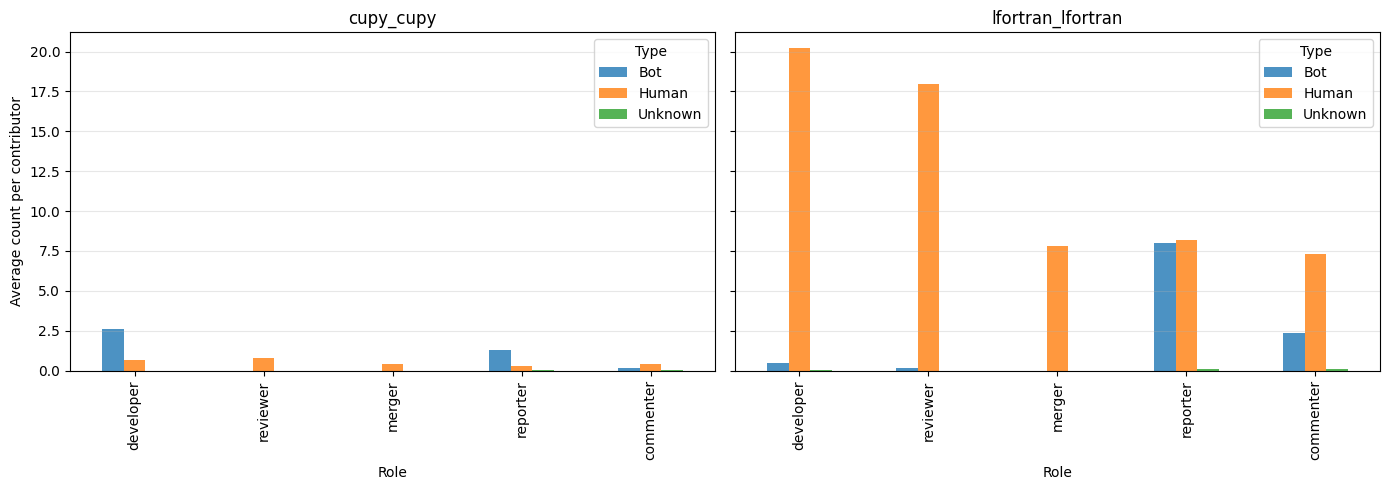

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (proj, df) in enumerate(role_with_labels.items()):
    # Prepare data: mean per role, split by rabbit_type
    means = df.groupby('rabbit_type')[['developer','reviewer','merger','reporter','commenter']].mean().T
    
    # Plot
    means.plot(kind='bar', ax=axes[idx], alpha=0.8)
    axes[idx].set_title(proj)
    axes[idx].set_xlabel('Role')
    axes[idx].set_ylabel('Average count per contributor')
    axes[idx].legend(title='Type')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Question 3.5:**  
Examine the bar charts. In which project do bots show the most specialised behaviour (i.e., high average in a few roles, near zero in others)? Which roles do bots dominate? What does this suggest about the purpose of bots in each project?

*Your answer here.*  Spécialisation des Bots

En comparant les graphiques à barres  et les moyennes obtenues, on peut identifier des stratégies d'automatisation très différentes selon les projets :

1. Projet avec le comportement le plus spécialisé

C'est dans LFortran que les bots sont les plus spécialisés.

Observation : Comme le confirme le dernier résultat de code, un bot "typique" sur LFortran effectue 8.00 actions de Reporter en moyenne, contre presque aucune action de développement (0.50) ou de revue (0.17).

Analyse : Le graphique montre une barre bleue (Bot) isolée et très haute pour "Reporter". Cela signifie que les bots ne touchent pas au code mais servent presque exclusivement à générer des rapports.

2. Rôles dominés par les bots

Dans CuPy : Les bots dominent le rôle de Révélateur (Developer) (2.61 vs 0.66 pour les humains). C'est surprenant car, d'habitude, les humains codent plus. Cela suggère que les bots ici sont des "travailleurs de fond" qui effectuent de nombreuses petites modifications techniques automatiques.

Dans LFortran : Les bots égalent presque les humains sur le rôle de Reporter (8.00 pour les bots vs 8.20 pour les humains). Ils sont donc les principaux moteurs de la création de tickets (issues).

3. Interprétation du rôle des bots

Bots de CuPy (Maintenance de structure) : Leur activité de "Developer" suggère l'utilisation de bots de type Dependabot ou des scripts de refactoring qui ouvrent des Pull Requests pour mettre à jour des bibliothèques ou corriger le style du code.

Bots de LFortran (Monitoring et Alertes) : Leur spécialisation extrême en "Reporter" suggère qu'ils sont liés à des systèmes de tests (CI/CD). Lorsqu'un test échoue sur une version du compilateur, le bot crée automatiquement une "Issue" détaillée. Ils servent de sentinelles pour la qualité du projet.

## Section 4: Comparative Behavioral Analysis

In this final section, we bring together everything we have learned about the two projects, their contributors and the roles they play. Our goal is to compare:

- The overall **behavioral profiles** of each project.
- How **bots and humans** differ in their activities.
- The **differences between the two projects** and possible explanations.
- Whether observed differences are **statistically significant**.

By the end, you will have a comprehensive understanding of how bots and humans collaborate (or not) in these open‑source projects and what factors might shape their behavior.

### 4.1. Profiling Contributor Behavior per Project

First, let’s build a high‑level picture of each project’s contributor activity. We’ll use the data we have prepared:
- **Event categories** (from Section 1), e.g., Issues, Pull Requests, Commits, Repository events.
- **Role counts** (from Section 3), e.g., how many times contributors acted as developers, reviewers, etc.

Run the cell below to see a quick summary of each project’s events.

In [ ]:
# Assuming we have:
#   - project_dfs: dict of DataFrames with project events (from Section 1)
#   - role_with_labels: dict of DataFrames with role counts per contributor + rabbit_type (from Section 3)

for proj_name, df_events in project_dfs.items():
    print(f"\n📊 PROJECT: {proj_name}")
    print("-" * 50)
    print(f"Total events: {len(df_events)}")
    print(f"Unique contributors: {df_events['actor.login'].nunique()}")
    print(f"Time span: {df_events['created_at'].min().date()} to {df_events['created_at'].max().date()}")
    
    # Event category distribution
    cat_counts = df_events['event_category'].value_counts()
    print("\nEvent categories:")
    for cat, count in cat_counts.items():
        print(f"  {cat}: {count} ({count/len(df_events)*100:.1f}%)")

**TODO 4.1:** Compute the **average number of events per contributor** for each project (total events divided by unique contributors). Print the values and comment on which project has a higher average.

In [ ]:
# TODO: Compute and print average events per contributor for each project.

**Question 4.1:**  
Look at the event category distributions. Which project has a higher proportion of **Pull Request**‑related events? Which has more **Repository** events? What might this suggest about the type of work happening in each project?

*Your answer here.*

Now let's examine the role distributions, how many contributors perform each role and how many activities they contribute.

In [ ]:
def project_role_profile(role_df, project_name):
    """Print and visualise role profile for a project."""
    print(f"\n👥 Role profile for {project_name}:")
    # Number of contributors active in each role (at least one action)
    role_presence = (role_df[['developer','reviewer','merger','reporter','commenter']] > 0).sum()
    print("\nContributors involved in each role:")
    print(role_presence.to_string())
    
    # Total activities per role
    role_totals = role_df[['developer','reviewer','merger','reporter','commenter']].sum()
    print("\nTotal activities per role:")
    print(role_totals.to_string())
    
    return role_presence, role_totals

profiles = {}
for proj, df_role in role_with_labels.items():
    profiles[proj] = project_role_profile(df_role, proj)

**TODO 4.2:** For each project, calculate the **ratio of total reviewer activities to total developer activities**. Print both ratios. (e.g., `reviewer/developer`). If developer total is zero, print "N/A".

In [ ]:
# TODO: Compute reviewer/developer ratio for each project.

**Question 4.2:**  
Which project has a higher reviewer‑to‑developer ratio? What might this indicate about the code review culture in that project (e.g., more thorough review, more reviewers per PR)?

*Your answer here.*

### 4.2. Comparing Bots and Humans: Who Does What?

Now we separate contributors by their type (bot vs. human) and compare their activity within each project. We use the merged DataFrames `role_with_labels` that contain a `rabbit_type` column.

In [ ]:
roles = ['developer', 'reviewer', 'merger', 'reporter', 'commenter']
projects = list(role_with_labels.keys())

def compare_bot_human_means(merged_df, project_name):
    grouped = merged_df.groupby('rabbit_type')[roles].mean()
    return grouped

for proj, df in role_with_labels.items():
    print(f"\n🤖 vs 🧑 {proj}")
    display(compare_bot_human_means(df, proj).round(2))

**TODO 4.3:** In the second project, compute the **median** (instead of mean) for each role for bots and humans. Use `.median()`. Print the results in a readable format.

In [ ]:
# TODO: Compute median role counts for bots and humans in the second project.

**Question 4.3:**  
Look at the mean tables. In which project do bots have a **higher** average for the `reporter` role than humans? What kinds of tasks might bots be automating as reporters (e.g., opening issues, commenting on own issues)?

*Your answer here.*

Grouped bar charts give a quick visual comparison.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for idx, (proj, df) in enumerate(role_with_labels.items()):
    means = df.groupby('rabbit_type')[roles].mean().T  # roles as rows, types as columns
    means.plot(kind='bar', ax=axes[idx], alpha=0.8)
    axes[idx].set_title(proj)
    axes[idx].set_xlabel('Role')
    axes[idx].set_ylabel('Mean activities per contributor')
    axes[idx].legend(title='Type')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Box plots show the full distribution (including outliers, exclude them when needed) and can reveal whether bots are more uniform.

In [ ]:
for proj, df in role_with_labels.items():
    # Melt the DataFrame to long format for seaborn
    df_melt = df.melt(id_vars=['contributor','rabbit_type'], 
                      value_vars=roles, 
                      var_name='role', value_name='count')
    
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df_melt, x='role', y='count', hue='rabbit_type')
    #plt.title(f'{proj} - Activity distribution per role by contributor type')
    #plt.yscale('log')  # because many zeros and large ranges
    #plt.grid(axis='y', alpha=0.3)
    plt.show()

**Question 4.4:**  
Examine the box plots. Do bots tend to have **less variability** (narrower boxes) than humans? Why might that be? Which role shows the most striking difference in variability between bots and humans?

*Your answer here.*

### 4.3. Project-Level Differences: What Explains the Variation?

Now we directly compare the two projects to understand how they differ and hypothesise why.

**Quantify differences in bot presence and role distribution**

In [ ]:
comparison = pd.DataFrame(index=[PROJECT_1_NAME, PROJECT_2_NAME])

for proj, df in role_with_labels.items():
    # Bot percentage among contributors
    bot_count = (df['rabbit_type'] == 'Bot').sum()
    total_contrib = len(df)
    comparison.loc[proj, 'Bot % (contributors)'] = f"{bot_count/total_contrib*100:.1f}%"
    
    # Bot percentage of total activities (sum of all roles)
    bot_activities = df[df['rabbit_type'] == 'Bot'][roles].sum().sum()
    total_activities = df[roles].sum().sum()
    comparison.loc[proj, 'Bot % (activities)'] = f"{bot_activities/total_activities*100:.1f}%"

display(comparison)

**TODO 4.4:** Compute the **ratio of bot activity percentage to bot contributor percentage** for each project. This tells you whether bots are more or less active than their numbers suggest. Print both ratios.

In [ ]:
# TODO: Compute (Bot % activities) / (Bot % contributors) for each project.

**Question 4.5:**  
In which project are bots **over‑represented** in terms of activity compared to their share of contributors? What does this imply about the intensity of bot activity in that project?

*Your answer here.*

**Compare role distributions** using a stacked bar chart of total activities (or contributor counts) split by type.

In [ ]:
# Prepare data for stacked bars
stack_data = []
for proj in projects:
    df = role_with_labels[proj]
    for role in roles:
        for typ in ['Bot', 'Human']:
            val = df[df['rabbit_type']==typ][role].sum()
            stack_data.append({'Project': proj, 'Role': role, 'Type': typ, 'Activities': val})

stack_df = pd.DataFrame(stack_data)

# Plot stacked bars per project
g = sns.catplot(data=stack_df, kind='bar', x='Role', y='Activities', hue='Type', col='Project', 
                palette={'Bot':'coral','Human':'skyblue'}, alpha=0.8, height=5, aspect=0.8)
g.set_axis_labels('Role', 'Total activities')
g.add_legend()
plt.show()

**Question 4.6:**  
Look at the stacked bars. In which project do bots contribute a visible share of `developer` activities? In which project do they contribute most to `reporter`? Based on your knowledge of typical bot tasks (e.g., dependency updates, issue triage), do these patterns make sense?

*Your answer here.*

### 4.4. Statistical Validation and Key Takeaways

Finally, we check whether the observed differences are statistically meaningful and we summarise our main findings.

**Are bots and humans really different? (per project, per role)**

We use the **Mann‑Whitney U test** to compare the distributions of activity counts for each role between bots and humans. This test does not assume normality and is suitable for count data with many zeros.

In [ ]:
from scipy.stats import mannwhitneyu

for proj in projects:
    df = role_with_labels[proj]
    bots = df[df['rabbit_type'] == 'Bot']
    humans = df[df['rabbit_type'] == 'Human']
    
    print(f"\n🔬 Statistical tests for {proj}")
    print("-" * 40)
    for role in roles:
        if len(bots) > 0 and len(humans) > 0:
            stat, p = mannwhitneyu(bots[role], humans[role], alternative='two-sided')
            print(f"{role:12s}: p = {p:.4f} {'(significant)' if p < 0.05 else '(not significant)'}")
        else:
            print(f"{role:12s}: insufficient data")

**TODO 4.5:** For any role where the p‑value is less than 0.05, compute the **mean difference** (bot mean minus human mean) to see the direction of the difference. Print a short summary.

In [ ]:
# TODO: For each significant role, compute and print bot_mean - human_mean.

**Question 4.7:**  
Interpret the statistical results. Are there any roles where bots and humans differ significantly? If yes, what does that tell you about the specialisation of bots? If no significant differences were found, does that mean bots and humans behave the same? Why might the test not detect differences even if means look different?

*Your answer here.*

**Are the two projects significantly different?**

We can compare, for example, the overall activity per contributor (total of all roles) between the two projects or the proportion of bot activity. A simple test: Mann‑Whitney on the total activity per contributor.

In [ ]:
# Create a combined DataFrame with project identifier
combined = pd.concat([
    role_with_labels[proj].assign(project=proj) for proj in projects
], ignore_index=True)

# Compare total activity (sum of all roles) between projects
total_activity = combined[roles].sum(axis=1)
combined['total_activity'] = total_activity

proj1_data = combined[combined['project']==projects[0]]['total_activity']
proj2_data = combined[combined['project']==projects[1]]['total_activity']

stat, p = mannwhitneyu(proj1_data, proj2_data, alternative='two-sided')
print(f"Comparison of total activity per contributor between projects: p = {p:.4f}")

If `p < 0.05`, we conclude that the overall activity levels differ significantly between the two projects.

**Question 4.8:**  
Based on the p‑value, do the two projects have significantly different levels of contributor activity? What might explain this difference (e.g., project size, maturity, development phase)?

*Your answer here.*